<a href="https://colab.research.google.com/github/tendolkarurja/IPD_Finance/blob/main/ESG_XAI_(Temporal_Autoregression_LSTM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ESG-XAI: Interpretable Sentiment-Driven Volatility
# Mapping ESG News to Indian Energy Stock Behaviour via FinBERT, SBERT, LSTM & SHAP
# Research Questions

# RQ1 — Does the hybrid ESG-NLP score (FinBERT + SBERT) predict short-term abnormal returns for Indian energy firms?
# RQ2 — Which linguistic tokens (SHAP attribution) are most associated with negative cumulative abnormal returns?
# RQ3 — Do financial SHAP attributions and environmental SHAP attributions converge or diverge per headline?
# Pipeline

# ET Headlines (2022–2025)
#     → Data Prep & Multi-company Normalisation  [Notebook 1 — IPD_Fin]
#     → FinBERT Financial Sentiment              [Notebook 2 — model_apply]
#     → SBERT Environmental Materiality          [Notebook 2 — model_apply]
#     → Temporal Alignment & Event Study (CAR)   [THIS NOTEBOOK — Section 3]
#     → LSTM Volatility Prediction               [THIS NOTEBOOK — Section 4]
#     → SHAP Token + Feature Explainability      [THIS NOTEBOOK — Section 5]
#     → Visualisations & Research Outputs        [THIS NOTEBOOK — Section 6]
# References

# Araci, D. (2019). FinBERT: Financial Sentiment Analysis with Pre-trained Language Models. arXiv:1908.10063
# Reimers & Gurevych (2019). Sentence-BERT. EMNLP 2019
# Lundberg & Lee (2017). A Unified Approach to Interpreting Model Predictions (SHAP). NeurIPS 2017
# MacKinlay (1997). Event Studies in Economics and Finance. JEL 35(1)
# Hochreiter & Schmidhuber (1997). Long Short-Term Memory. Neural Computation 9(8)
# Lim et al. (2021). Temporal Fusion Transformers for Interpretable Multi-horizon Time Series Forecasting. IJF
# Section 0 — Install Dependencies & Imports

# ── Install all required packages ──────────────────────────────────────────
!pip install -q transformers torch sentence-transformers shap yfinance scipy statsmodels scikit-learn matplotlib seaborn pandas numpy
# Note: if SHAP version conflicts with numba, run:
# !pip uninstall -y numba shap && pip install shap

import warnings, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from datetime import timedelta
from scipy.stats import pearsonr, spearmanr, ttest_1samp
from statsmodels.stats.multitest import multipletests

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from sentence_transformers import SentenceTransformer, util

import yfinance as yf
import shap
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)

print("All imports successful.")
print(f"PyTorch: {torch.__version__} | CUDA available: {torch.cuda.is_available()}")

# All imports successful.
# PyTorch: 2.11.0+cpu | CUDA available: False
# Section 1 — Data Preparation
# Sourced from IPD_Fin.ipynb. Key improvements:

# Multi-company headlines are exploded into one row per company (fixes ambiguous yfinance lookup)
# Sector label added for heterogeneity controls
# company field standardised to canonical ticker map

from google.colab import drive
drive.mount('/content/drive')

# ── Company list, ticker map, sector map ─────────────────────────────────
COMPANIES = ['RELIANCE','ADANI','TATA POWER','NTPC','ONGC',
             'JSW','NHPC','POWER GRID','BPCL','GAIL','IOCL']

# Yahoo Finance tickers (NSE)
TICKER_MAP = {
    'RELIANCE':   'RELIANCE.NS',
    'ADANI':      'ADANIGREEN.NS',
    'TATA POWER': 'TATAPOWER.NS',
    'NTPC':       'NTPC.NS',
    'ONGC':       'ONGC.NS',
    'JSW':        'JSWENERGY.NS',
    'NHPC':       'NHPC.NS',
    'POWER GRID': 'POWERGRID.NS',
    'BPCL':       'BPCL.NS',
    'GAIL':       'GAIL.NS',
    'IOCL':       'IOC.NS',
}

# Sector labels for regression controls
SECTOR_MAP = {
    'RELIANCE':   'oil_gas',
    'ADANI':      'renewable',
    'TATA POWER': 'renewable',
    'NTPC':       'thermal_power',
    'ONGC':       'oil_gas',
    'JSW':        'renewable',
    'NHPC':       'renewable',
    'POWER GRID': 'transmission',
    'BPCL':       'oil_gas',
    'GAIL':       'oil_gas',
    'IOCL':       'oil_gas',
}

ESG_KEYWORDS = (
    'CARBON|NET ZERO|RENEWABLE|EMISSIONS|DECARBONIZATION|GREEN HYDROGEN|BIOFUEL|EV|'
    'SOLAR|WIND|HYDRO|CLEAN|POLLUTION|WASTE|SPILL|FLY ASH|EFFLUENT|CLIMATE|'
    'BIODIVERSITY|ECOLOGY|SUSTAINABILITY|METHANE|SEQUESTRATION|AMMONIA'
)

NOISE_PHRASES = ['stocks in news','sensex','nifty','top losers','top gainers',
                 'should you buy','market news','closing bell','opening bell',
                 'technical view','stock pick','brokerage view']



# ── If you already have energy_headlines.csv, load it directly instead ─────
# This cell loads the pre-built CSV and applies the same explode + enrich logic.
# Skip this cell if you ran Section 1 above from scratch.

df_raw = pd.read_csv('/content/drive/MyDrive/energy_headlines.csv')
df_raw['Date'] = pd.to_datetime(df_raw['Date'])

# Explode multi-company rows  (e.g. "NTPC,JSW" -> 2 rows)
df_raw['company'] = df_raw['company'].str.split(',')
df_esg = df_raw.explode('company')
df_esg['company'] = df_esg['company'].str.strip()
df_esg = df_esg[df_esg['company'].isin(TICKER_MAP)].copy()
df_esg['ticker'] = df_esg['company'].map(TICKER_MAP)
df_esg['sector'] = df_esg['company'].map(SECTOR_MAP)
df_esg = df_esg.reset_index(drop=True)

print(f"Loaded & exploded: {len(df_esg)} rows")
print(df_esg['company'].value_counts())




# ESG-XAI: Interpretable Sentiment-Driven Volatility
## Mapping ESG News to Indian Energy Stock Behaviour via FinBERT, SBERT, LSTM & SHAP

**Research Questions**
- **RQ1** — Does the hybrid ESG-NLP score (FinBERT + SBERT) predict short-term abnormal returns for Indian energy firms?
- **RQ2** — Which linguistic tokens (SHAP attribution) are most associated with negative cumulative abnormal returns?
- **RQ3** — Do *financial* SHAP attributions and *environmental* SHAP attributions converge or diverge per headline?

**Pipeline**
```
ET Headlines (2022–2025)
    → Data Prep & Multi-company Normalisation  [Notebook 1 — IPD_Fin]
    → FinBERT Financial Sentiment              [Notebook 2 — model_apply]
    → SBERT Environmental Materiality          [Notebook 2 — model_apply]
    → Temporal Alignment & Event Study (CAR)   [THIS NOTEBOOK — Section 3]
    → LSTM Volatility Prediction               [THIS NOTEBOOK — Section 4]
    → SHAP Token + Feature Explainability      [THIS NOTEBOOK — Section 5]
    → Visualisations & Research Outputs        [THIS NOTEBOOK — Section 6]
```

**References**
- Araci, D. (2019). *FinBERT: Financial Sentiment Analysis with Pre-trained Language Models.* arXiv:1908.10063
- Reimers & Gurevych (2019). *Sentence-BERT.* EMNLP 2019
- Lundberg & Lee (2017). *A Unified Approach to Interpreting Model Predictions (SHAP).* NeurIPS 2017
- MacKinlay (1997). *Event Studies in Economics and Finance.* JEL 35(1)
- Hochreiter & Schmidhuber (1997). *Long Short-Term Memory.* Neural Computation 9(8)
- Lim et al. (2021). *Temporal Fusion Transformers for Interpretable Multi-horizon Time Series Forecasting.* IJF


## Section 0 — Install Dependencies & Imports

In [ ]:
# ── Install all required packages ──────────────────────────────────────────
!pip install -q transformers torch sentence-transformers shap yfinance scipy statsmodels scikit-learn matplotlib seaborn pandas numpy
# Note: if SHAP version conflicts with numba, run:
# !pip uninstall -y numba shap && pip install shap


In [ ]:
import warnings, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from datetime import timedelta
from scipy.stats import pearsonr, spearmanr, ttest_1samp
from statsmodels.stats.multitest import multipletests

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from sentence_transformers import SentenceTransformer, util

import yfinance as yf
import shap
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)

print("All imports successful.")
print(f"PyTorch: {torch.__version__} | CUDA available: {torch.cuda.is_available()}")


All imports successful.
PyTorch: 2.11.0+cpu | CUDA available: False


## Section 1 — Data Preparation
Sourced from `IPD_Fin.ipynb`. Key improvements:
- Multi-company headlines are **exploded** into one row per company (fixes ambiguous yfinance lookup)
- Sector label added for heterogeneity controls
- `company` field standardised to canonical ticker map


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ── Company list, ticker map, sector map ─────────────────────────────────
COMPANIES = ['RELIANCE','ADANI','TATA POWER','NTPC','ONGC',
             'JSW','NHPC','POWER GRID','BPCL','GAIL','IOCL']

# Yahoo Finance tickers (NSE)
TICKER_MAP = {
    'RELIANCE':   'RELIANCE.NS',
    'ADANI':      'ADANIGREEN.NS',
    'TATA POWER': 'TATAPOWER.NS',
    'NTPC':       'NTPC.NS',
    'ONGC':       'ONGC.NS',
    'JSW':        'JSWENERGY.NS',
    'NHPC':       'NHPC.NS',
    'POWER GRID': 'POWERGRID.NS',
    'BPCL':       'BPCL.NS',
    'GAIL':       'GAIL.NS',
    'IOCL':       'IOC.NS',
}

# Sector labels for regression controls
SECTOR_MAP = {
    'RELIANCE':   'oil_gas',
    'ADANI':      'renewable',
    'TATA POWER': 'renewable',
    'NTPC':       'thermal_power',
    'ONGC':       'oil_gas',
    'JSW':        'renewable',
    'NHPC':       'renewable',
    'POWER GRID': 'transmission',
    'BPCL':       'oil_gas',
    'GAIL':       'oil_gas',
    'IOCL':       'oil_gas',
}

ESG_KEYWORDS = (
    'CARBON|NET ZERO|RENEWABLE|EMISSIONS|DECARBONIZATION|GREEN HYDROGEN|BIOFUEL|EV|'
    'SOLAR|WIND|HYDRO|CLEAN|POLLUTION|WASTE|SPILL|FLY ASH|EFFLUENT|CLIMATE|'
    'BIODIVERSITY|ECOLOGY|SUSTAINABILITY|METHANE|SEQUESTRATION|AMMONIA'
)

NOISE_PHRASES = ['stocks in news','sensex','nifty','top losers','top gainers',
                 'should you buy','market news','closing bell','opening bell',
                 'technical view','stock pick','brokerage view']


In [ ]:

# ── If you already have energy_headlines.csv, load it directly instead ─────
# This cell loads the pre-built CSV and applies the same explode + enrich logic.
# Skip this cell if you ran Section 1 above from scratch.

df_raw = pd.read_csv('/content/drive/MyDrive/energy_headlines.csv')
df_raw['Date'] = pd.to_datetime(df_raw['Date'])

# Explode multi-company rows  (e.g. "NTPC,JSW" -> 2 rows)
df_raw['company'] = df_raw['company'].str.split(',')
df_esg = df_raw.explode('company')
df_esg['company'] = df_esg['company'].str.strip()
df_esg = df_esg[df_esg['company'].isin(TICKER_MAP)].copy()
df_esg['ticker'] = df_esg['company'].map(TICKER_MAP)
df_esg['sector'] = df_esg['company'].map(SECTOR_MAP)
df_esg = df_esg.reset_index(drop=True)

print(f"Loaded & exploded: {len(df_esg)} rows")
print(df_esg['company'].value_counts())


Loaded & exploded: 318 rows
company
TATA POWER    87
NTPC          67
ADANI         66
RELIANCE      25
JSW           24
NHPC          15
ONGC          12
BPCL           9
GAIL           7
IOCL           3
POWER GRID     3
Name: count, dtype: int64


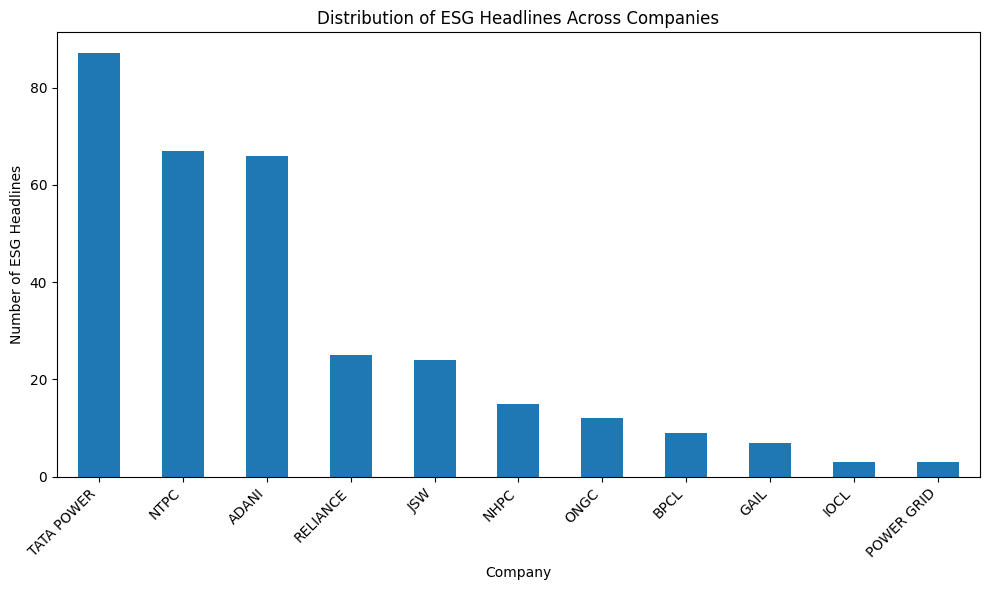

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Count headlines per company
company_counts = df_esg['company'].value_counts().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10,6))
company_counts.plot(kind='bar')

plt.title('Distribution of ESG Headlines Across Companies')
plt.xlabel('Company')
plt.ylabel('Number of ESG Headlines')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Section 2 — NLP Scoring: FinBERT + SBERT
Dual-score per headline:
- `fin_score` = FinBERT positive − negative (financial sentiment direction)
- `env_score` = SBERT cosine similarity to environmental anchor (materiality)
- `composite_score` = weighted combination (alpha·fin + (1-alpha)·env)

**Reference:** Araci 2019 (FinBERT), Reimers & Gurevych 2019 (SBERT)


In [ ]:
# ── Load FinBERT ──────────────────────────────────────────────────────────
FINBERT_PATH = '/content/drive/MyDrive/environment_FINBERT'

if os.path.exists(FINBERT_PATH) and os.listdir(FINBERT_PATH):
    print("Loading FinBERT from local cache...")
    local_tok   = AutoTokenizer.from_pretrained(FINBERT_PATH)
    local_model = AutoModelForSequenceClassification.from_pretrained(FINBERT_PATH)
    sentiment_pipe = pipeline('sentiment-analysis', model=local_model,
                               tokenizer=local_tok, top_k=None)
else:
    print("Downloading ProsusAI/finbert (first run only)...")
    sentiment_pipe = pipeline('sentiment-analysis', model='ProsusAI/finbert', top_k=None)
    os.makedirs(FINBERT_PATH, exist_ok=True)
    sentiment_pipe.model.save_pretrained(FINBERT_PATH)
    sentiment_pipe.tokenizer.save_pretrained(FINBERT_PATH)
    print("Saved to local cache.")

print("FinBERT ready.")


Loading FinBERT from local cache...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT ready.


In [ ]:
# ── FIX 5: FinBERT scored on masked headline, not raw ────────────────────
#
# Problem: "NTPC signs green deal" → FinBERT attends heavily to "NTPC"
# (high-frequency financial entity), diluting the ESG signal.
# Fix: apply masking before scoring so ESG language drives the score.

# Build entity masker (same logic as SHAP section — defined here once)
import re

_MASK_PHRASES = sorted(
    list(TICKER_MAP.keys()),
    key=len, reverse=True
)
# Also mask common subsidiary names to avoid confusing FinBERT
_EXTRA_MASK = ['RELIANCE JIO','ADANI PORTS','JSW STEEL','TATA MOTORS',
               'TATA STEEL','ONGC VIDESH','ADANI ENTERPRISES']
_MASK_PHRASES = sorted(set(_MASK_PHRASES + _EXTRA_MASK), key=len, reverse=True)

def mask_entities(text):
    """Replace company names with COMPANY / COMPANY-2 tokens."""
    if not isinstance(text, str):
        return text
    counter, seen = 1, {}
    def repl(m):
        nonlocal counter
        name = m.group(0).upper()
        if name not in seen:
            seen[name] = 'COMPANY' if counter == 1 else f'COMPANY-{counter}'
            counter += 1
        return seen[name]
    result = text
    for phrase in _MASK_PHRASES:
        pat = r'\b' + re.escape(phrase) + r'\b'
        result = re.sub(pat, repl, result, flags=re.IGNORECASE)
    return result

# Apply masking to full dataset
df_esg['headline_masked'] = df_esg['Headline'].apply(mask_entities)

# Verify
_ex = "NTPC and ONGC launch green hydrogen pilot at Rajasthan solar park"
print(f"Raw    : {_ex}")
print(f"Masked : {mask_entities(_ex)}")
print()

def finbert_scores(text):
    """Return dict with positive/negative/neutral probabilities."""
    try:
        results = sentiment_pipe(str(text)[:512])
        if isinstance(results[0], list):
            return {item['label'].lower(): item['score'] for item in results[0]}
        else:
            out = {'positive': 0.0, 'negative': 0.0, 'neutral': 0.0}
            out[results[0]['label'].lower()] = results[0]['score']
            return out
    except Exception:
        return {'positive': 0.0, 'negative': 0.0, 'neutral': 1.0}

print("Applying FinBERT to masked headlines...")
scores_df = df_esg['headline_masked'].apply(finbert_scores).apply(pd.Series)
df_esg = pd.concat([df_esg, scores_df], axis=1)
df_esg['fin_score'] = df_esg['positive'] - df_esg['negative']

print("FinBERT done.")
print(df_esg[['headline_masked','positive','negative','fin_score']].head(3))


Raw    : NTPC and ONGC launch green hydrogen pilot at Rajasthan solar park
Masked : COMPANY-2 and COMPANY launch green hydrogen pilot at Rajasthan solar park

Applying FinBERT to masked headlines...
FinBERT done.
                                                                            headline_masked  \
0  COMPANY becomes promoter in Sterling and Wilson Renewable Energy, holds over 40 pc stake   
1                         Sterling and Wilson Renewable rise 2% as COMPANY becomes promoter   
2       COMPANY, GEDCOL JV to set up India's largest floating solar power project in Odisha   

   positive  negative  fin_score  
0  0.078661  0.010354   0.068308  
1  0.943564  0.023040   0.920523  
2  0.477738  0.007568   0.470170  


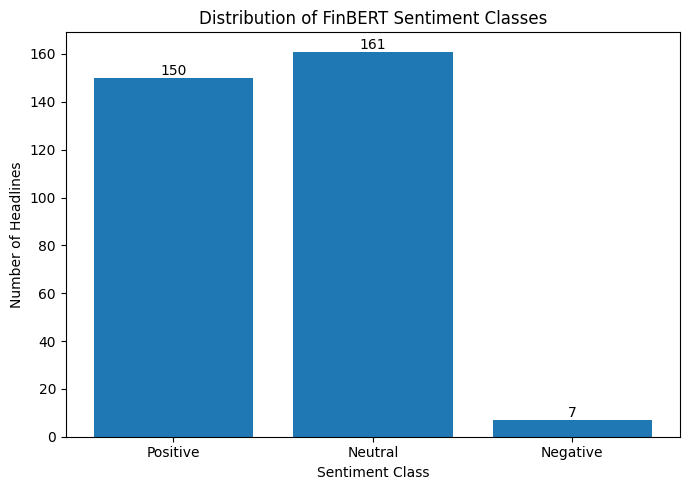

In [ ]:
import matplotlib.pyplot as plt

sentiment_counts = (
    df_esg['sentiment']
    .value_counts()
    .reindex(['Positive', 'Neutral', 'Negative'])
    .fillna(0)
)

plt.figure(figsize=(7,5))

bars = plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

plt.title('Distribution of FinBERT Sentiment Classes')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Headlines')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [ ]:
# ── SBERT Environmental Materiality Score ─────────────────────────────────
# Reference: Reimers & Gurevych (2019) — Sentence-BERT
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

ENV_ANCHOR = (
    "Renewable energy, solar power, carbon emissions reduction, "
    "net zero targets, environmental sustainability, and climate change."
)
anchor_emb = sbert_model.encode(ENV_ANCHOR, convert_to_tensor=True)

def env_materiality(text):
    """Cosine similarity of headline to environmental anchor sentence."""
    emb = sbert_model.encode(str(text), convert_to_tensor=True)
    return float(util.cos_sim(emb, anchor_emb).item())

print("Applying SBERT materiality scoring...")
df_esg['env_score'] = df_esg['Headline'].apply(env_materiality)  # range: 0 to 1

print("SBERT done.")
print(df_esg[['Headline','fin_score','env_score']].head(3))


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Applying SBERT materiality scoring...
SBERT done.
                                                                                    Headline  \
0  Reliance becomes promoter in Sterling and Wilson Renewable Energy, holds over 40 pc stake   
1                         Sterling and Wilson Renewable rise 2% as Reliance becomes promoter   
2           NHPC, GEDCOL JV to set up India's largest floating solar power project in Odisha   

   fin_score  env_score  
0   0.068308   0.245557  
1   0.920523   0.217401  
2   0.470170   0.307734  


<Figure size 1200x600 with 0 Axes>

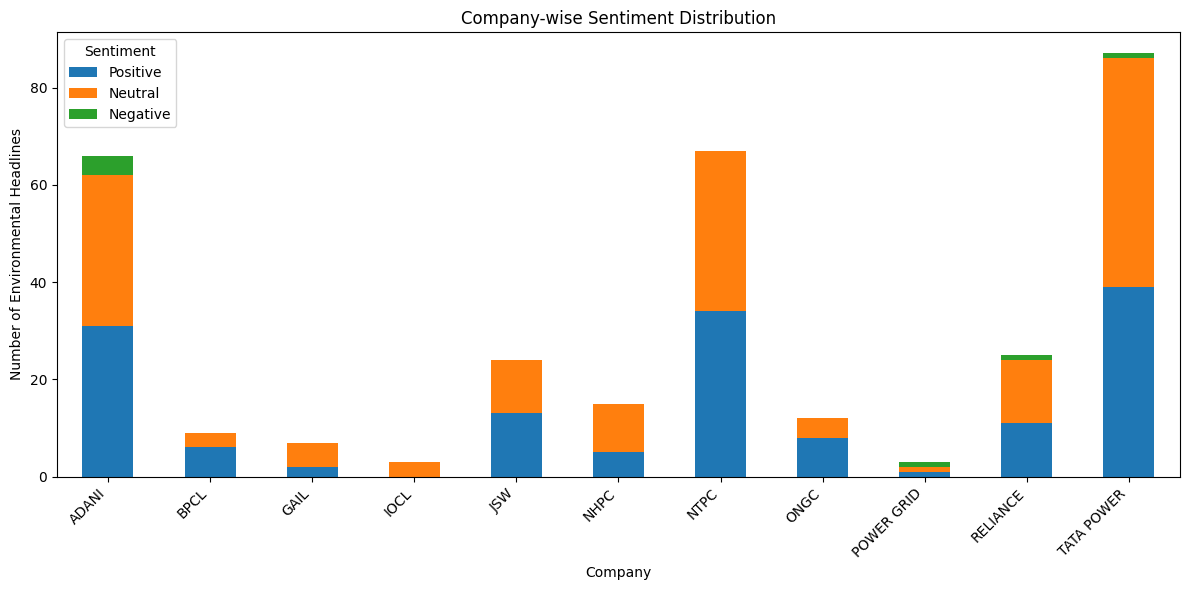

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

sentiment_company = pd.crosstab(
    df_esg['company'],
    df_esg['sentiment']
)

# Ensure consistent order
sentiment_company = sentiment_company.reindex(
    columns=['Positive', 'Neutral', 'Negative'],
    fill_value=0
)

plt.figure(figsize=(12,6))

sentiment_company.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Company-wise Sentiment Distribution')
plt.xlabel('Company')
plt.ylabel('Number of Environmental Headlines')

plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')

plt.tight_layout()
plt.show()

In [ ]:
#── FIX 4: composite_score — normalise both signals to same range ─────────
#
# Problem: fin_score ∈ [−1,+1] (signed); env_score ∈ [0,+1] (unsigned).
# Mixing them directly means env always pushes composite positive.
# Fix: rescale env_score to [−1,+1] by centering: 2·env − 1.
# Both signals are now symmetric around 0.

df_esg['env_score_scaled'] = 2 * df_esg['env_score'] - 1  # [0,1] → [−1,+1]

ALPHA = 0.6   # will be tuned below; used for main analysis

df_esg['composite_score'] = (ALPHA * df_esg['fin_score']
                              + (1 - ALPHA) * df_esg['env_score_scaled'])

def label_sentiment(score):
    if score > 0.3:  return 'Positive'
    if score < -0.3: return 'Negative'
    return 'Neutral'

df_esg['sentiment'] = df_esg['fin_score'].apply(label_sentiment)

print("Score ranges after normalisation:")
print(df_esg[['fin_score','env_score','env_score_scaled','composite_score']].describe().round(3))
print("\nSentiment distribution:")
print(df_esg['sentiment'].value_counts())

df_esg.to_csv('/content/drive/MyDrive/esg_scored.csv', index=False)
print("\nSaved: esg_scored.csv")

# ── Alpha sensitivity analysis ────────────────────────────────────────────
# Run after Section 3 (CAR available). Uncomment and re-run once CAR is computed.

alpha_grid = [0.1, 0.3, 0.5, 0.7, 0.9]
alpha_results = []
for a in alpha_grid:
    cs = a * df_esg['fin_score'] + (1 - a) * df_esg['env_score_scaled']
    merged = pd.DataFrame({'cs': cs, 'CAR': df_esg['CAR']}).dropna()
    r, p = pearsonr(merged['cs'], merged['CAR'])
    alpha_results.append({'alpha': a, 'pearson_r': round(r, 4), 'p': round(p, 4)})
print("\nAlpha sensitivity (choose alpha that maximises |r|):")
print(pd.DataFrame(alpha_results).to_string(index=False))


Score ranges after normalisation:
       fin_score  env_score  env_score_scaled  composite_score
count    318.000    318.000           318.000          318.000
mean       0.370      0.265            -0.471            0.034
std        0.345      0.077             0.154            0.218
min       -0.956      0.037            -0.926           -0.832
25%        0.129      0.216            -0.568           -0.114
50%        0.265      0.269            -0.461           -0.005
75%        0.702      0.315            -0.370            0.214
max        0.927      0.528             0.057            0.451

Sentiment distribution:
sentiment
Neutral     161
Positive    150
Negative      7
Name: count, dtype: int64

Saved: esg_scored.csv


KeyError: 'CAR'

## Section 3 — Event Study: Cumulative Abnormal Returns (CAR), AAR, Sentiment Wise Split, etc.
**Standard methodology** from MacKinlay (1997):
1. Estimate market model parameters (α, β) from estimation window [-120, -11] trading days before each event
2. Compute abnormal return (AR) = actual return − expected return (CAPM)
3. Aggregate over event window [-1, +5] → **CAR[-1,+5]**
4. Test whether mean CAR is significantly different from zero (t-test)
5. Regress CAR on `composite_score` to answer **RQ1**

Market benchmark: **NIFTY 50** (^NSEI)


In [ ]:
# ── Download NIFTY 50 benchmark ───────────────────────────────────────────
print("Downloading NIFTY 50 data (2021-2025)...")
nifty = yf.download('^NSEI', start='2021-06-01', end='2025-06-30',
                    auto_adjust=True, progress=False)['Close']
nifty_ret = nifty.pct_change().dropna()
nifty_ret.index = nifty_ret.index.tz_localize(None)
print(f"NIFTY trading days: {len(nifty_ret)}")


NIFTY trading days: 1008


In [ ]:
# ── Download all company price data ───────────────────────────────────────
price_data = {}
for company, ticker in TICKER_MAP.items():
    try:
        px = yf.download(ticker, start='2021-06-01', end='2025-06-30',
                         auto_adjust=True, progress=False)['Close']
        px.index = px.index.tz_localize(None)
        price_data[company] = px.pct_change().dropna()
        print(f"  {company:12s} ({ticker}): {len(px)} trading days")
    except Exception as e:
        print(f"  {company}: FAILED — {e}")

print(f"\nDownloaded {len(price_data)} tickers.")


  RELIANCE     (RELIANCE.NS): 1009 trading days
  ADANI        (ADANIGREEN.NS): 1009 trading days
  TATA POWER   (TATAPOWER.NS): 1009 trading days
  NTPC         (NTPC.NS): 1009 trading days
  ONGC         (ONGC.NS): 1009 trading days
  JSW          (JSWENERGY.NS): 1009 trading days
  NHPC         (NHPC.NS): 1009 trading days
  POWER GRID   (POWERGRID.NS): 1009 trading days
  BPCL         (BPCL.NS): 1009 trading days
  GAIL         (GAIL.NS): 1009 trading days
  IOCL         (IOC.NS): 1009 trading days

Downloaded 11 tickers.


In [ ]:
# CONSIDERS SINGLE EVENT, IGNORES ALL OTHER EVENTS THAT OCCUR WITHIN 10 days of the said current event for the mentioned company.

In [ ]:
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# ── FIX 3a: compute_car — hard return None on truncated windows ───────────
# Old code: max(0, evt_start) silently used a shorter window.
# New code: returns None if event window cannot be fully formed.

def compute_car(company, event_date, window_pre=(-1, 5), estimation=(-120, -11)):
    """
    Compute CAR[-1,+5] via OLS market model (MacKinlay 1997).
    Returns None on any data insufficiency rather than silently truncating.
    """
    stock_df = price_data.get(company)
    if stock_df is None:
        return None

    stock_ret  = stock_df.squeeze()
    market_ret = nifty_ret.squeeze()

    combined = pd.DataFrame({'stock': stock_ret, 'market': market_ret}).dropna()

    if event_date not in combined.index:
        future = combined.index[combined.index >= event_date]
        if len(future) == 0:
            return None
        event_date = future[0]

    t0_loc = combined.index.get_loc(event_date)

    est_start = t0_loc + estimation[0]   # e.g. t0 - 120
    est_end   = t0_loc + estimation[1]   # e.g. t0 - 11

    # ── FIX: hard reject if estimation or event window cannot be formed ───
    if est_start < 0 or est_end <= est_start:
        return None

    evt_start = t0_loc + window_pre[0]   # t0 - 1
    evt_end   = t0_loc + window_pre[1] + 1  # t0 + 6

    if evt_start < 0 or evt_end > len(combined):   # was: max(0, evt_start)
        return None

    est_window = combined.iloc[est_start:est_end]
    if len(est_window) < 30:
        return None

    X = add_constant(est_window['market'].values)
    y = est_window['stock'].values

    try:
        model     = OLS(y, X).fit()
        alpha_hat = model.params[0]
        beta_hat  = model.params[1]
        resid_std = model.resid.std()
    except Exception:
        return None

    evt_window = combined.iloc[evt_start:evt_end]
    AR = (evt_window['stock'].values
          - (alpha_hat + beta_hat * evt_window['market'].values))
    CAR = AR.sum()

    # Event-level t-stat (for Patell/BMP use in next cell)
    SE     = resid_std * np.sqrt(len(AR))
    t_stat = CAR / SE if SE > 0 else np.nan

    return {
        'CAR':             round(CAR * 100, 4),
        't_stat':          round(t_stat, 3),
        'SAR':             round((CAR * 100) / (resid_std * 100 * np.sqrt(len(AR))), 4) if SE > 0 else np.nan,
        'resid_std':       resid_std,
        'n_event_days':    len(AR),
        'alpha_hat':       round(alpha_hat, 6),
        'beta_hat':        round(beta_hat, 4),
        'AR_series':       AR.tolist(),
        'event_date_used': event_date,
    }


In [ ]:

# -- Apply CAR to every headline -------------------------------------------------
print("Computing CARs for all events (may take 2-5 minutes)...")

car_results = []
for idx, row in df_esg.iterrows():
    result = compute_car(row['company'], pd.Timestamp(row['Date']))
    if result:
        car_results.append({
            'idx':             idx,
            'CAR':             result['CAR'],
            't_stat_car':      result['t_stat'],
            'SAR':             result.get('SAR', np.nan),
            'resid_std':       result.get('resid_std', np.nan),
            'n_event_days':    result.get('n_event_days', np.nan),
            'beta':            result['beta_hat'],
            'event_date_used': result['event_date_used'],
            'AR_series':       result.get('AR_series', None),
        })

if not car_results:
    raise RuntimeError("No valid CAR events were computed. Check price coverage and event dates.")

df_car = pd.DataFrame(car_results).set_index('idx')

# Drop stale CAR columns if the cell is rerun in the same Colab session.
for col in df_car.columns:
    if col in df_esg.columns:
        df_esg = df_esg.drop(columns=col)

df_esg = df_esg.join(df_car)

valid = df_esg['CAR'].notna()
print(f"\nCAR computed for {valid.sum()} / {len(df_esg)} events")
print(df_esg.loc[valid, ['company','Date','fin_score','env_score','env_score_scaled','composite_score','CAR']].head(6).round(3))


Computing CARs for all events (may take 2-5 minutes)...

CAR computed for 318 / 318 events
      company       Date  fin_score  env_score  env_score_scaled  \
0    RELIANCE 2022-01-03      0.068      0.246            -0.509   
1    RELIANCE 2022-01-04      0.921      0.217            -0.565   
2        NHPC 2022-01-06      0.470      0.308            -0.385   
3  TATA POWER 2022-01-17      0.100      0.309            -0.382   
4        NTPC 2022-01-19      0.704      0.307            -0.386   
5         JSW 2022-01-20      0.170      0.253            -0.494   

   composite_score    CAR  
0           -0.163 -2.557  
1            0.326 -1.544  
2            0.128 -2.230  
3           -0.093  1.751  
4            0.268  5.800  
5           -0.096  1.289  


Events before deduplication : 318
Events after deduplication  : 218
Removed overlapping windows : 100

  AGGREGATE EVENT STUDY  (Window: [-1, +5])
  Market benchmark: NIFTY 50 | primary sample: deduplicated
  N events after dedup    : 218
  Mean CAR                : -0.5693%
  Median CAR              : -0.7490%
  Std CAR                 : 7.5115%
  Standard t-stat / p     : -1.1189 / 0.2644
  BMP t-stat / p          : -0.8521 / 0.3951
  Significant (BMP, 0.05) : NO

Mean CAR by FinBERT sentiment (deduplicated):
            mean    std  count
sentiment                     
Negative   3.235  7.503      3
Neutral   -1.601  8.228    108
Positive   0.365  6.613    107

Mean CAR by sector (deduplicated):
                mean    std  count
sector                            
oil_gas        0.277  4.302     43
renewable     -0.884  9.164    131
thermal_power -0.490  3.499     42
transmission   0.184  1.325      2


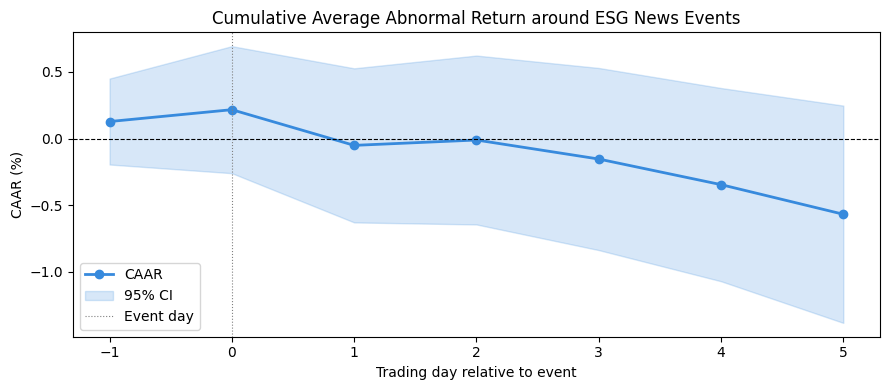

CAAR plot saved. Events with full 7-day AR series: 218


In [ ]:

# -- Robust event study: deduplication + BMP statistic --------------------------
# Overlapping event windows inflate the apparent sample size. We keep only the
# first valid event per company within a 7-calendar-day window, then report both
# the ordinary one-sample t-test and a cross-sectional BMP-style statistic.

from scipy.stats import ttest_1samp
from scipy.stats import t as t_dist

if 'CAR' not in df_esg.columns:
    raise RuntimeError("Run the CAR computation cell before the event-study summary.")

df_esg = df_esg.sort_values(['company', 'Date']).copy()

def drop_overlapping(group, min_gap_days=7):
    keep = []
    last = pd.Timestamp('1900-01-01')
    for idx, row in group.sort_values('Date').iterrows():
        if pd.isnull(row['CAR']):
            continue
        if (row['Date'] - last).days >= min_gap_days:
            keep.append(idx)
            last = row['Date']
    return keep

keep_idx = []
for company, grp in df_esg.groupby('company'):
    keep_idx.extend(drop_overlapping(grp, min_gap_days=7))

df_esg_clean = df_esg.loc[keep_idx].sort_values('Date').copy()

print(f"Events before deduplication : {df_esg['CAR'].notna().sum()}")
print(f"Events after deduplication  : {df_esg_clean['CAR'].notna().sum()}")
print(f"Removed overlapping windows : {df_esg['CAR'].notna().sum() - df_esg_clean['CAR'].notna().sum()}")

car_vals = df_esg_clean['CAR'].dropna().values
if len(car_vals) < 3:
    raise RuntimeError("Too few deduplicated CAR events for inference.")

t_stat, p_val = ttest_1samp(car_vals, 0)

sar_vals = df_esg_clean['SAR'].replace([np.inf, -np.inf], np.nan).dropna().values
if len(sar_vals) >= 3 and np.std(sar_vals, ddof=1) > 0:
    bmp_t = sar_vals.mean() / (sar_vals.std(ddof=1) / np.sqrt(len(sar_vals)))
    bmp_p = 2 * t_dist.sf(abs(bmp_t), df=len(sar_vals)-1)
else:
    bmp_t, bmp_p = np.nan, np.nan

print("\n" + "=" * 58)
print("  AGGREGATE EVENT STUDY  (Window: [-1, +5])")
print("  Market benchmark: NIFTY 50 | primary sample: deduplicated")
print("=" * 58)
print(f"  N events after dedup    : {len(car_vals)}")
print(f"  Mean CAR                : {car_vals.mean():.4f}%")
print(f"  Median CAR              : {np.median(car_vals):.4f}%")
print(f"  Std CAR                 : {car_vals.std(ddof=1):.4f}%")
print(f"  Standard t-stat / p     : {t_stat:.4f} / {p_val:.4f}")
print(f"  BMP t-stat / p          : {bmp_t:.4f} / {bmp_p:.4f}")
print(f"  Significant (BMP, 0.05) : {'YES' if pd.notna(bmp_p) and bmp_p < 0.05 else 'NO'}")
print("=" * 58)

print("\nMean CAR by FinBERT sentiment (deduplicated):")
print(df_esg_clean.groupby('sentiment')['CAR'].agg(['mean','std','count']).round(3))

print("\nMean CAR by sector (deduplicated):")
print(df_esg_clean.groupby('sector')['CAR'].agg(['mean','std','count']).round(3))

# CAAR plot using full event-window abnormal-return series.
car_results_indexed = {r['idx']: r for r in car_results}
ar_all = []
for idx in df_esg_clean.index:
    r = car_results_indexed.get(idx)
    ar = r.get('AR_series') if r else None
    if isinstance(ar, list) and len(ar) == 7:
        ar_all.append(ar)

if ar_all:
    ar_matrix = np.array(ar_all)
    caar_daily = ar_matrix.mean(axis=0) * 100
    caar_cum = np.cumsum(caar_daily)
    se_cum = np.sqrt(np.cumsum((ar_matrix.std(axis=0, ddof=1) * 100 / np.sqrt(len(ar_all))) ** 2))
    days = list(range(-1, 6))

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(days, caar_cum, 'o-', color='#378ADD', lw=2, label='CAAR')
    ax.fill_between(days, caar_cum - 1.96 * se_cum, caar_cum + 1.96 * se_cum,
                    alpha=0.2, color='#378ADD', label='95% CI')
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.axvline(0, color='gray', lw=0.8, linestyle=':', label='Event day')
    ax.set_xlabel('Trading day relative to event')
    ax.set_ylabel('CAAR (%)')
    ax.set_title('Cumulative Average Abnormal Return around ESG News Events')
    ax.set_xticks(days)
    ax.legend()
    plt.tight_layout()
    SHAP_OUT_DIR = '/content/drive/MyDrive/SHAP_outputs/'
    os.makedirs(SHAP_OUT_DIR, exist_ok=True)
    plt.savefig(f'{SHAP_OUT_DIR}CAAR_event_window.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"CAAR plot saved. Events with full 7-day AR series: {len(ar_all)}")
else:
    print("CAAR plot skipped: AR_series unavailable. Rerun compute_car and CAR application cells.")


In [ ]:
df_esg = pd.read_csv('/content/drive/MyDrive/esg_with_CAR.csv')
df_esg_clean = pd.read_csv('/content/drive/MyDrive/esg_with_CAR_dedup.csv')

In [ ]:
# -- RQ1 regression: composite score -> CAR -------------------------------------
# Use the deduplicated event-study sample for the main regression. Clustered
# standard errors by company are reported because event outcomes are not iid.

import statsmodels.formula.api as smf

reg_source = df_esg_clean.copy() if 'df_esg_clean' in globals() else df_esg.copy()
reg_cols = ['CAR','composite_score','fin_score','env_score_scaled','sector','company','Date']
df_reg = reg_source[reg_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

if len(df_reg) < 30:
    raise RuntimeError("Too few valid rows for the CAR regression.")

m1 = smf.ols('CAR ~ composite_score', data=df_reg).fit(
    cov_type='cluster', cov_kwds={'groups': df_reg['company']}
)
m2 = smf.ols('CAR ~ composite_score + C(sector)', data=df_reg).fit(
    cov_type='cluster', cov_kwds={'groups': df_reg['company']}
)
m3 = smf.ols('CAR ~ fin_score + env_score_scaled + C(sector)', data=df_reg).fit(
    cov_type='cluster', cov_kwds={'groups': df_reg['company']}
)

print(f"Regression sample: {len(df_reg)} deduplicated events across {df_reg['company'].nunique()} companies")
print("\nModel 1 - Simple OLS with company-clustered SE:")
print(m1.summary().tables[1])
print(f"\nR2 = {m1.rsquared:.4f} | p(composite_score) = {m1.pvalues['composite_score']:.4f}")

print("\nModel 2 - Sector controls, company-clustered SE:")
print(m2.summary().tables[1])

print("\nModel 3 - Fin + scaled environmental scores, company-clustered SE:")
print(m3.summary().tables[1])
print(f"\nR2(m3) = {m3.rsquared:.4f}")

# Save both full and cleaned event data for downstream cells / reporting.
df_esg.to_csv('/content/drive/MyDrive/esg(strict)_with_CAR.csv', index=False)
df_esg_clean.to_csv('/content/drive/MyDrive/esg(strict)_with_CAR_dedup.csv', index=False)
print("\nSaved: esg(strict)_with_CAR.csv and esg(strict)_with_CAR_dedup.csv")


Regression sample: 218 deduplicated events across 11 companies

Model 1 - Simple OLS with company-clustered SE:
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.6801      0.368     -1.848      0.065      -1.401       0.041
composite_score     2.3352      2.447      0.954      0.340      -2.460       7.131

R2 = 0.0038 | p(composite_score) = 0.3399

Model 2 - Sector controls, company-clustered SE:
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      0.1383      0.674      0.205      0.837      -1.183       1.460
C(sector)[T.renewable]        -1.1215      0.693     -1.618      0.106      -2.480       0.237
C(sector)[T.thermal_power]    -0.7386      0.638     -1.158      0.247      -1.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 4
  warnings.warn('covariance of constraints does not have full '



Saved: esg(strict)_with_CAR.csv and esg(strict)_with_CAR_dedup.csv


In [ ]:
# ============================================================
# TEMPORAL EVENT STUDY: AR / AAR / CAAR from t=-5 to t=+10
# ============================================================

from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from scipy.stats import ttest_1samp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EVENT_PRE = 5
EVENT_POST = 10
ESTIMATION = (-120, -11)

def compute_event_ar_path(company, event_date, event_pre=EVENT_PRE, event_post=EVENT_POST,
                          estimation=ESTIMATION):
    stock_df = price_data.get(company)

    if stock_df is None:
        return None

    stock_ret = stock_df.squeeze()
    market_ret = nifty_ret.squeeze()

    combined = pd.DataFrame({
        'stock': stock_ret,
        'market': market_ret
    }).dropna()

    event_date = pd.Timestamp(event_date)

    if event_date not in combined.index:
        future = combined.index[combined.index >= event_date]

        if len(future) == 0:
            return None

        event_date = future[0]

    t0_loc = combined.index.get_loc(event_date)

    est_start = t0_loc + estimation[0]
    est_end = t0_loc + estimation[1]

    evt_start = t0_loc - event_pre
    evt_end = t0_loc + event_post + 1

    if est_start < 0 or est_end <= est_start:
        return None

    if evt_start < 0 or evt_end > len(combined):
        return None

    est_window = combined.iloc[est_start:est_end]
    evt_window = combined.iloc[evt_start:evt_end]

    if len(est_window) < 30 or len(evt_window) != event_pre + event_post + 1:
        return None

    X = add_constant(est_window['market'].values)
    y = est_window['stock'].values

    try:
        model = OLS(y, X).fit()
        alpha_hat, beta_hat = model.params
    except Exception:
        return None

    expected = alpha_hat + beta_hat * evt_window['market'].values
    ar = evt_window['stock'].values - expected

    out = {
        'company': company,
        'event_date': event_date
    }

    for lag, val in zip(range(-event_pre, event_post + 1), ar):
        out[f'AR_{lag:+d}'] = val * 100

    return out


event_paths = []

event_source = df_esg_clean if 'df_esg_clean' in globals() else df_esg

for idx, row in event_source.dropna(subset=['CAR']).iterrows():
    result = compute_event_ar_path(
        row['company'],
        row['Date'],
        event_pre=EVENT_PRE,
        event_post=EVENT_POST
    )

    if result is not None:
        result['fin_score'] = row['fin_score']
        result['env_score_scaled'] = row['env_score_scaled']
        result['composite_score'] = row['composite_score']
        result['sentiment'] = row['sentiment']
        result['sector'] = row['sector']
        result['Headlines'] = row['Headline']
        event_paths.append(result)

event_path_df = pd.DataFrame(event_paths)

print("Event paths computed:", len(event_path_df))
event_path_df.head()

Event paths computed: 218


,company,event_date,AR_-5,AR_-4,AR_-3,AR_-2,AR_-1,AR_+0,AR_+1,AR_+2,...,AR_+7,AR_+8,AR_+9,AR_+10,fin_score,env_score_scaled,composite_score,sentiment,sector,Headlines
0,RELIANCE,2022-01-03,-0.741878,0.085580,0.283498,-1.766143,-0.733592,-0.473396,0.957327,-0.401886,...,1.558704,0.222551,0.130360,0.134799,0.068308,-0.508886,-0.162570,Neutral,oil_gas,"Reliance becomes promoter in Sterling and Wilson Renewable Energy, holds over 40 pc stake"
1,NHPC,2022-01-06,1.868673,-1.939603,-0.836459,-0.639068,-0.310717,2.563109,-3.155863,-0.047309,...,0.383535,0.402312,0.143275,-0.619604,0.470170,-0.384532,0.128289,Positive,renewable,"NHPC, GEDCOL JV to set up India's largest floating solar power project in Odisha"
2,TATA POWER,2022-01-17,-1.519247,-0.384808,-0.008359,2.283376,-0.790087,0.452504,-2.057722,5.222139,...,2.245450,0.887361,-2.125673,-1.357122,0.099838,-0.382287,-0.093012,Neutral,renewable,Tata Power Renewable Energy commissions 100 MW solar projs in Uttar Pradesh
3,NTPC,2022-01-19,0.301251,0.581775,0.322458,0.645531,-0.069761,0.850173,1.120483,0.225088,...,-0.048994,-2.013480,-1.164626,0.911277,0.703596,-0.386154,0.267696,Positive,thermal_power,NTPC invites bids from developers to build 900-MW solar photovoltaic parks in Cuba
4,JSW,2022-01-20,-1.080474,-0.405629,1.270498,-2.076784,3.998585,1.842273,-2.148336,-0.435213,...,-0.787940,-2.471232,0.316021,-1.181188,0.169811,-0.494036,-0.095728,Neutral,renewable,JSW to soon announce first green hydrogen project


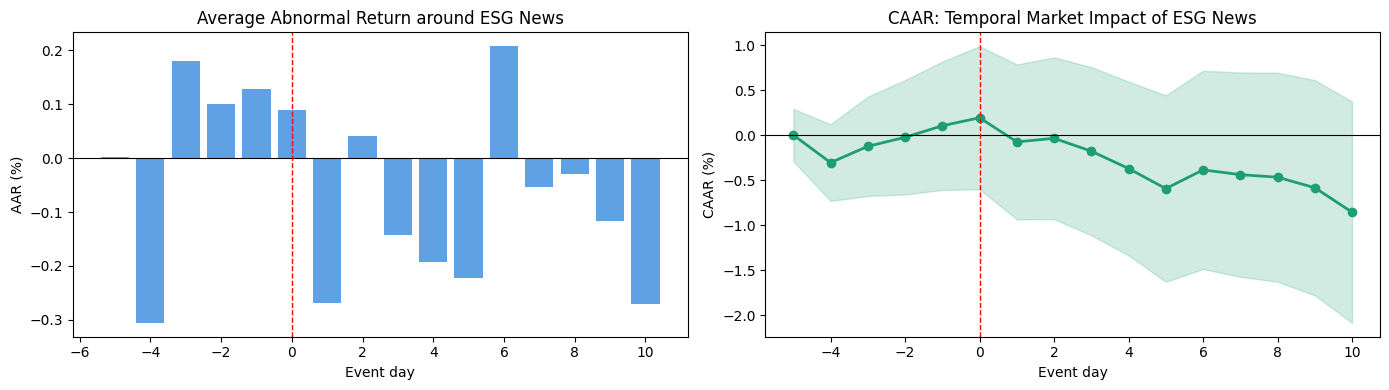

In [ ]:

# ============================================================
# AAR / CAAR PLOT
# ============================================================

ar_cols = [f'AR_{lag:+d}' for lag in range(-EVENT_PRE, EVENT_POST + 1)]
lags = list(range(-EVENT_PRE, EVENT_POST + 1))

aar = event_path_df[ar_cols].mean()
aar_se = event_path_df[ar_cols].std(ddof=1) / np.sqrt(len(event_path_df))

caar = aar.cumsum()
caar_se = np.sqrt((aar_se ** 2).cumsum())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(lags, aar.values, color='#378ADD', alpha=0.8)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].axvline(0, color='red', linestyle='--', lw=1)
axes[0].set_title('Average Abnormal Return around ESG News')
axes[0].set_xlabel('Event day')
axes[0].set_ylabel('AAR (%)')

axes[1].plot(lags, caar.values, marker='o', color='#1D9E75', lw=2)
axes[1].fill_between(
    lags,
    caar.values - 1.96 * caar_se.values,
    caar.values + 1.96 * caar_se.values,
    color='#1D9E75',
    alpha=0.2
)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].axvline(0, color='red', linestyle='--', lw=1)
axes[1].set_title('CAAR: Temporal Market Impact of ESG News')
axes[1].set_xlabel('Event day')
axes[1].set_ylabel('CAAR (%)')

plt.tight_layout()
plt.show()

In [ ]:

# ============================================================
# EVENT-DAY SIGNIFICANCE TABLE
# ============================================================

sig_rows = []

for lag, col in zip(lags, ar_cols):
    vals = event_path_df[col].dropna()
    t_stat, p_val = ttest_1samp(vals, 0)

    sig_rows.append({
        'event_day': lag,
        'AAR_percent': vals.mean(),
        't_stat': t_stat,
        'p_value': p_val,
        'significant_5pct': p_val < 0.05
    })

aar_sig_df = pd.DataFrame(sig_rows)

print(aar_sig_df.round(4).to_string(index=False))

 event_day  AAR_percent  t_stat  p_value  significant_5pct
        -5       0.0012  0.0079   0.9937             False
        -4      -0.3056 -1.9294   0.0550             False
        -3       0.1808  1.0128   0.3123             False
        -2       0.1003  0.6236   0.5336             False
        -1       0.1275  0.7740   0.4398             False
         0       0.0891  0.4969   0.6197             False
         1      -0.2682 -1.6036   0.1103             False
         2       0.0402  0.3033   0.7619             False
         3      -0.1429 -1.0936   0.2753             False
         4      -0.1924 -1.5560   0.1212             False
         5      -0.2226 -1.1682   0.2440             False
         6       0.2076  1.0862   0.2786             False
         7      -0.0527 -0.3791   0.7050             False
         8      -0.0287 -0.2292   0.8189             False
         9      -0.1167 -0.8030   0.4229             False
        10      -0.2709 -1.8437   0.0666             Fal

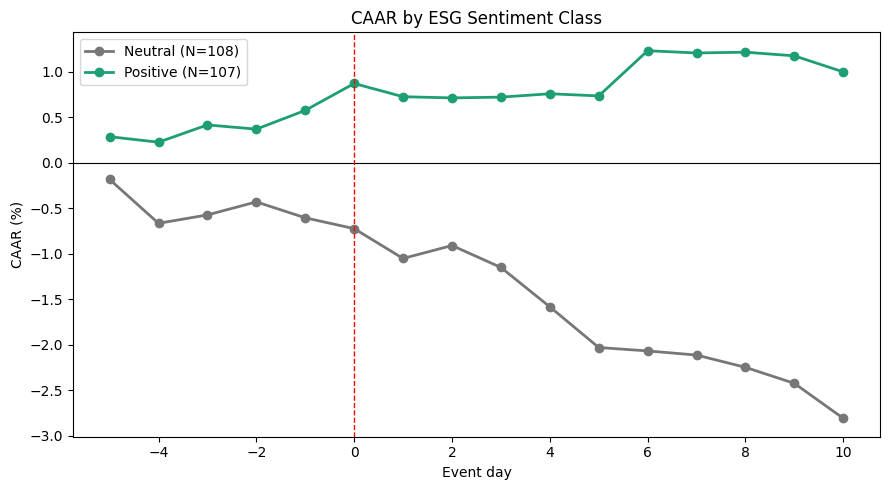

In [ ]:
# ============================================================
# SENTIMENT-WISE CAAR
# ============================================================

plt.figure(figsize=(9, 5))

colors = {
    'Positive': '#1D9E75',
    'Negative': '#E24B4A',
    'Neutral': '#777777'
}

for sentiment, grp in event_path_df.groupby('sentiment'):
    if len(grp) < 5:
        continue

    aar_s = grp[ar_cols].mean()
    caar_s = aar_s.cumsum()

    plt.plot(
        lags,
        caar_s.values,
        marker='o',
        lw=2,
        label=f'{sentiment} (N={len(grp)})',
        color=colors.get(sentiment, None)
    )

plt.axhline(0, color='black', lw=0.8)
plt.axvline(0, color='red', linestyle='--', lw=1)
plt.title('CAAR by ESG Sentiment Class')
plt.xlabel('Event day')
plt.ylabel('CAAR (%)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# MULTI-WINDOW CAR TABLE
# ============================================================

windows = {
    'CAR[-1,+1]': (-1, 1),
    'CAR[0,+1]': (0, 1),
    'CAR[0,+3]': (0, 3),
    'CAR[0,+5]': (0, 5),
    'CAR[0,+10]': (0, 10),
    'CAR[-5,+10]': (-5, 10)
}

window_rows = []

for name, (start, end) in windows.items():
    cols = [f'AR_{lag:+d}' for lag in range(start, end + 1)]
    vals = event_path_df[cols].sum(axis=1).dropna()

    t_stat, p_val = ttest_1samp(vals, 0)

    window_rows.append({
        'window': name,
        'N': len(vals),
        'mean_CAR_percent': vals.mean(),
        'median_CAR_percent': vals.median(),
        't_stat': t_stat,
        'p_value': p_val,
        'significant_5pct': p_val < 0.05
    })

car_window_df = pd.DataFrame(window_rows)

print(car_window_df.round(4).to_string(index=False))

     window   N  mean_CAR_percent  median_CAR_percent  t_stat  p_value  significant_5pct
 CAR[-1,+1] 218           -0.0516             -0.2922 -0.1474   0.8830             False
  CAR[0,+1] 218           -0.1791             -0.3004 -0.6273   0.5311             False
  CAR[0,+3] 218           -0.2818             -0.2423 -0.7909   0.4299             False
  CAR[0,+5] 218           -0.6968             -0.6953 -1.5081   0.1330             False
 CAR[0,+10] 218           -0.9582             -0.5055 -1.3703   0.1720             False
CAR[-5,+10] 218           -0.8541             -0.8913 -0.9515   0.3424             False


In [ ]:
event_path_df.sentiment.value_counts()

,count
sentiment,
Neutral,108
Positive,107
Negative,3


In [ ]:
event_path_df['CAR_0_10'] = event_path_df[[f'AR_{lag:+d}' for lag in range(0, 11)]].sum(axis=1)

cols = ['company', 'event_date', 'sentiment', 'Headlines', 'fin_score', 'env_score_scaled', 'CAR_0_10']

event_path_df.sort_values('CAR_0_10').head(15)[cols]

,company,event_date,sentiment,Headlines,fin_score,env_score_scaled,CAR_0_10
71,ADANI,2023-01-19,Neutral,adani enterprises fpo 20000 crore green hydrogen ambitions and debt repayment,0.197502,-0.444170,-69.521909
73,ADANI,2023-02-02,Neutral,"No impact of Adani Group firms' stock rout, India has 15 to 16 large firms in renewables, says R K Singh",0.059275,-0.573720,-63.927417
75,ADANI,2023-02-09,Neutral,"Adani Green, Gas JV healthy; hydrogen plan on hold: TotalEnergies",0.186990,-0.637565,-39.583193
28,ADANI,2022-05-30,Neutral,Adani Green arm commissions India's first wind-solar hybrid power plant in Jaisalmer,0.278480,-0.417247,-21.813770
7,TATA POWER,2022-02-08,Positive,Tata Power in advanced talks to raise $600-700 million for its renewable energy biz,0.650452,-0.538377,-16.421104
155,JSW,2024-02-27,Positive,JSW Energy gets 700 MW solar project from SJVN,0.351820,-0.493234,-14.841307
59,JSW,2022-11-02,Positive,"Strong manufacturing base, supply chain needed to make solar power viable at current tariff: Prashant Jain, JSW Energy",0.416765,-0.184894,-14.779834
29,NTPC,2022-06-13,Positive,Amara Raja bags contract from NTPC to set up green hydrogen fuelling station in Leh,0.735660,-0.863122,-12.536333
202,ADANI,2024-12-02,Negative,YSR's superfast green light of the Adani solar deal raises eyebrows; Chandrababu Naidu to review it,-0.408110,-0.651375,-12.386773
153,NHPC,2024-02-26,Neutral,"80% of total capex will be in hydro sector; 15-20% in solar and hybrid green energy sector: RP Goyal, NHPC",0.024562,-0.212046,-11.915885


In [ ]:
# ============================================================
# NEWS-CLUSTER EVENT STUDY
# Groups overlapping ESG headlines into firm-level news cycles
# ============================================================

CLUSTER_GAP_DAYS = 7

df_events = df_esg[df_esg['CAR'].notna()].copy()
df_events = df_events.sort_values(['company', 'Date']).copy()

cluster_rows = []

for company, grp in df_events.groupby('company'):
    grp = grp.sort_values('Date').copy()

    current_cluster = []
    cluster_id = 0
    last_date = None

    for idx, row in grp.iterrows():
        row_date = pd.Timestamp(row['Date'])

        if last_date is None:
            current_cluster = [(idx, row)]
            last_date = row_date
            continue

        gap = (row_date - last_date).days

        if gap <= CLUSTER_GAP_DAYS:
            current_cluster.append((idx, row))
            last_date = row_date
        else:
            # Save previous cluster
            cluster_df = pd.DataFrame([r for _, r in current_cluster])

            cluster_rows.append({
                'company': company,
                'cluster_id': f'{company}_{cluster_id}',
                'cluster_start': cluster_df['Date'].min(),
                'cluster_end': cluster_df['Date'].max(),
                'news_count': len(cluster_df),
                'mean_fin_score': cluster_df['fin_score'].mean(),
                'min_fin_score': cluster_df['fin_score'].min(),
                'max_fin_score': cluster_df['fin_score'].max(),
                'mean_env_score_scaled': cluster_df['env_score_scaled'].mean(),
                'mean_composite_score': cluster_df['composite_score'].mean(),
                'has_negative': int((cluster_df['fin_score'] < -0.3).any()),
                'has_positive': int((cluster_df['fin_score'] > 0.3).any()),
                'dominant_sentiment': cluster_df['sentiment'].mode().iloc[0],
                'headlines_joined': ' || '.join(cluster_df['Headline'].astype(str).head(5)),
            })

            cluster_id += 1
            current_cluster = [(idx, row)]
            last_date = row_date

    # Save last cluster
    if current_cluster:
        cluster_df = pd.DataFrame([r for _, r in current_cluster])

        cluster_rows.append({
            'company': company,
            'cluster_id': f'{company}_{cluster_id}',
            'cluster_start': cluster_df['Date'].min(),
            'cluster_end': cluster_df['Date'].max(),
            'news_count': len(cluster_df),
            'mean_fin_score': cluster_df['fin_score'].mean(),
            'min_fin_score': cluster_df['fin_score'].min(),
            'max_fin_score': cluster_df['fin_score'].max(),
            'mean_env_score_scaled': cluster_df['env_score_scaled'].mean(),
            'mean_composite_score': cluster_df['composite_score'].mean(),
            'has_negative': int((cluster_df['fin_score'] < -0.3).any()),
            'has_positive': int((cluster_df['fin_score'] > 0.3).any()),
            'dominant_sentiment': cluster_df['sentiment'].mode().iloc[0],
            'headlines_joined': ' || '.join(cluster_df['Headline'].astype(str).head(5)),
        })

df_clusters = pd.DataFrame(cluster_rows)

print("Original CAR-valid events:", len(df_events))
print("News clusters:", len(df_clusters))
print("\nCluster size distribution:")
print(df_clusters['news_count'].describe())

print("\nDominant sentiment distribution:")
print(df_clusters['dominant_sentiment'].value_counts())

df_clusters.head()

Original CAR-valid events: 318
News clusters: 190

Cluster size distribution:
count    190.000000
mean       1.673684
std        1.068472
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        7.000000
Name: news_count, dtype: float64

Dominant sentiment distribution:
dominant_sentiment
Neutral     104
Positive     81
Negative      5
Name: count, dtype: int64


,company,cluster_id,cluster_start,cluster_end,news_count,mean_fin_score,min_fin_score,max_fin_score,mean_env_score_scaled,mean_composite_score,has_negative,has_positive,dominant_sentiment,headlines_joined
0,ADANI,ADANI_0,2022-01-21,2022-01-21,1,0.794220,0.794220,0.794220,-0.859857,0.132589,0,1,Positive,"Adani expands his green plan, eyes foray into EVs"
1,ADANI,ADANI_1,2022-02-13,2022-02-13,1,0.611175,0.611175,0.611175,-0.925881,-0.003647,0,1,Positive,"The week that was in 10 stocks: Adani Wilmar zooms 72%, Solara Active, Jubilant disappoints"
2,ADANI,ADANI_2,2022-03-04,2022-03-04,1,0.221938,0.221938,0.221938,-0.259340,0.029427,0,0,Neutral,"SPI, Adani Solar to promote solar energy usage in rural areas of four states"
3,ADANI,ADANI_3,2022-04-13,2022-04-13,1,0.454394,0.454394,0.454394,-0.696397,-0.005922,0,1,Positive,gautam adanis green energy firm now even bigger than hdfc bajaj finance bharti airtel
4,ADANI,ADANI_4,2022-05-28,2022-05-28,1,0.278480,0.278480,0.278480,-0.417247,0.000189,0,0,Neutral,Adani Green arm commissions India's first wind-solar hybrid power plant in Jaisalmer


In [ ]:
# ============================================================
# AR / CAAR path for news clusters
# ============================================================

cluster_paths = []

for _, row in df_clusters.iterrows():
    result = compute_event_ar_path(
        row['company'],
        row['cluster_start'],
        event_pre=EVENT_PRE,
        event_post=EVENT_POST
    )

    if result is not None:
        result['cluster_id'] = row['cluster_id']
        result['cluster_start'] = row['cluster_start']
        result['cluster_end'] = row['cluster_end']
        result['news_count'] = row['news_count']
        result['mean_fin_score'] = row['mean_fin_score']
        result['min_fin_score'] = row['min_fin_score']
        result['max_fin_score'] = row['max_fin_score']
        result['mean_env_score_scaled'] = row['mean_env_score_scaled']
        result['mean_composite_score'] = row['mean_composite_score']
        result['has_negative'] = row['has_negative']
        result['has_positive'] = row['has_positive']
        result['dominant_sentiment'] = row['dominant_sentiment']
        result['headlines_joined'] = row['headlines_joined']

        cluster_paths.append(result)

cluster_path_df = pd.DataFrame(cluster_paths)

print("Cluster AR paths computed:", len(cluster_path_df))
cluster_path_df.head()

Cluster AR paths computed: 190


,company,event_date,AR_-5,AR_-4,AR_-3,AR_-2,AR_-1,AR_+0,AR_+1,AR_+2,...,news_count,mean_fin_score,min_fin_score,max_fin_score,mean_env_score_scaled,mean_composite_score,has_negative,has_positive,dominant_sentiment,headlines_joined
0,ADANI,2022-01-21,1.867930,7.566022,3.986496,2.400830,1.873905,-1.380085,-3.390706,4.100102,...,1,0.794220,0.794220,0.794220,-0.859857,0.132589,0,1,Positive,"Adani expands his green plan, eyes foray into EVs"
1,ADANI,2022-02-14,4.648235,-5.691562,-2.061086,-1.970326,0.462015,-0.393926,-1.792362,1.734755,...,1,0.611175,0.611175,0.611175,-0.925881,-0.003647,0,1,Positive,"The week that was in 10 stocks: Adani Wilmar zooms 72%, Solara Active, Jubilant disappoints"
2,ADANI,2022-03-04,-4.281413,1.861711,-5.171631,2.377884,3.578409,-2.377858,-3.720900,-2.192578,...,1,0.221938,0.221938,0.221938,-0.259340,0.029427,0,0,Neutral,"SPI, Adani Solar to promote solar energy usage in rural areas of four states"
3,ADANI,2022-04-13,0.523196,-1.159210,5.963947,14.775680,4.937514,2.306858,4.644413,-1.439381,...,1,0.454394,0.454394,0.454394,-0.696397,-0.005922,0,1,Positive,gautam adanis green energy firm now even bigger than hdfc bajaj finance bharti airtel
4,ADANI,2022-05-30,-1.510838,-5.167818,2.263370,-2.568991,-1.593751,-3.080894,-12.475926,-2.493713,...,1,0.278480,0.278480,0.278480,-0.417247,0.000189,0,0,Neutral,Adani Green arm commissions India's first wind-solar hybrid power plant in Jaisalmer


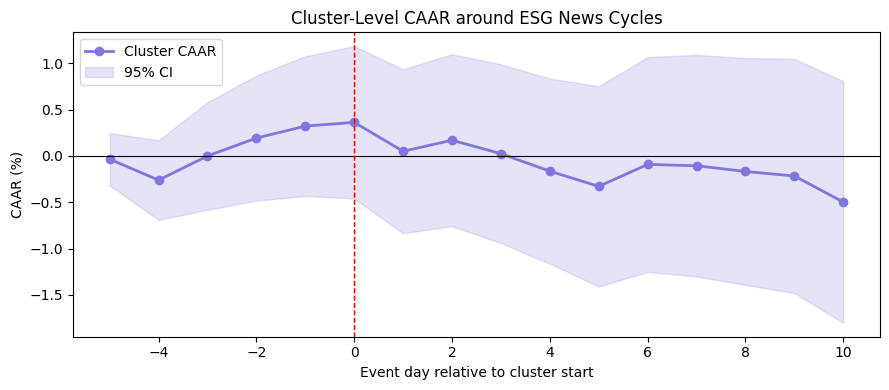

In [ ]:

# ============================================================
# Cluster-level AAR / CAAR
# ============================================================

cluster_ar_cols = [f'AR_{lag:+d}' for lag in range(-EVENT_PRE, EVENT_POST + 1)]
cluster_lags = list(range(-EVENT_PRE, EVENT_POST + 1))

cluster_aar = cluster_path_df[cluster_ar_cols].mean()
cluster_aar_se = cluster_path_df[cluster_ar_cols].std(ddof=1) / np.sqrt(len(cluster_path_df))

cluster_caar = cluster_aar.cumsum()
cluster_caar_se = np.sqrt((cluster_aar_se ** 2).cumsum())

plt.figure(figsize=(9, 4))

plt.plot(
    cluster_lags,
    cluster_caar.values,
    marker='o',
    lw=2,
    color='#7F77DD',
    label='Cluster CAAR'
)

plt.fill_between(
    cluster_lags,
    cluster_caar.values - 1.96 * cluster_caar_se.values,
    cluster_caar.values + 1.96 * cluster_caar_se.values,
    color='#7F77DD',
    alpha=0.2,
    label='95% CI'
)

plt.axhline(0, color='black', lw=0.8)
plt.axvline(0, color='red', linestyle='--', lw=1)
plt.title('Cluster-Level CAAR around ESG News Cycles')
plt.xlabel('Event day relative to cluster start')
plt.ylabel('CAAR (%)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Cluster-level multi-window CAR table
# ============================================================

cluster_window_rows = []

for name, (start, end) in windows.items():
    cols = [f'AR_{lag:+d}' for lag in range(start, end + 1)]
    vals = cluster_path_df[cols].sum(axis=1).dropna()

    t_stat, p_val = ttest_1samp(vals, 0)

    cluster_window_rows.append({
        'window': name,
        'N_clusters': len(vals),
        'mean_CAR_percent': vals.mean(),
        'median_CAR_percent': vals.median(),
        't_stat': t_stat,
        'p_value': p_val,
        'significant_5pct': p_val < 0.05
    })

cluster_car_window_df = pd.DataFrame(cluster_window_rows)

print(cluster_car_window_df.round(4).to_string(index=False))

     window  N_clusters  mean_CAR_percent  median_CAR_percent  t_stat  p_value  significant_5pct
 CAR[-1,+1]         190           -0.1428             -0.2804 -0.4492   0.6538             False
  CAR[0,+1]         190           -0.2720             -0.2635 -1.0611   0.2900             False
  CAR[0,+3]         190           -0.2978             -0.2296 -0.8632   0.3891             False
  CAR[0,+5]         190           -0.6514             -0.5043 -1.3466   0.1797             False
 CAR[0,+10]         190           -0.8212             -0.2657 -1.0969   0.2741             False
CAR[-5,+10]         190           -0.4982             -0.3417 -0.5540   0.5802             False


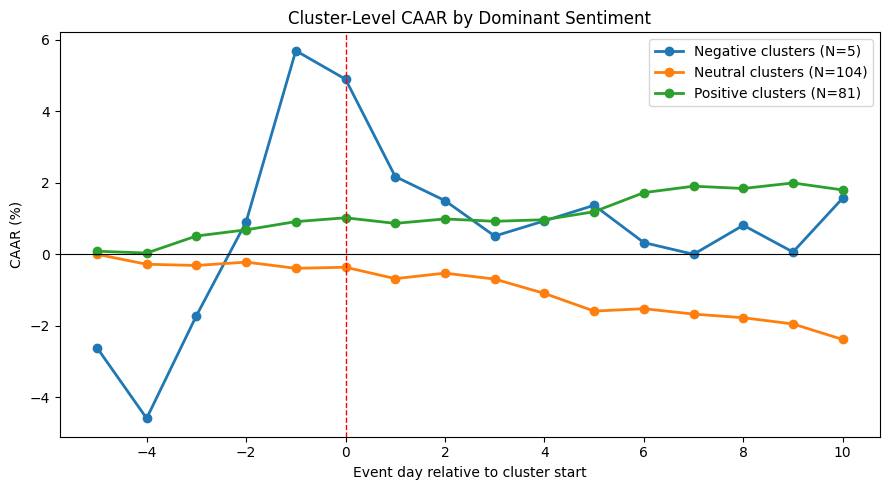

In [ ]:
# ============================================================
# Cluster CAAR by dominant sentiment
# ============================================================

plt.figure(figsize=(9, 5))

for sentiment, grp in cluster_path_df.groupby('dominant_sentiment'):
    if len(grp) < 5:
        continue

    aar_s = grp[cluster_ar_cols].mean()
    caar_s = aar_s.cumsum()

    plt.plot(
        cluster_lags,
        caar_s.values,
        marker='o',
        lw=2,
        label=f'{sentiment} clusters (N={len(grp)})'
    )

plt.axhline(0, color='black', lw=0.8)
plt.axvline(0, color='red', linestyle='--', lw=1)
plt.title('Cluster-Level CAAR by Dominant Sentiment')
plt.xlabel('Event day relative to cluster start')
plt.ylabel('CAAR (%)')
plt.legend()
plt.tight_layout()
plt.show()

## Section 4 — Volatility Impact

> Add blockquote


Builds a rolling-window LSTM that takes 30-day sequences of:
`[daily_return, volume_norm, fin_score_daily, env_score_daily, composite_score_daily]`
and predicts **5-day forward realised volatility** (std of returns over next 5 trading days).

This satisfies the topic's explicit mention of an LSTM for price series and enables **SHAP feature attribution across time**.

**Architecture:** 2-layer LSTM → Dropout(0.2) → Linear(1)
**Reference:** Hochreiter & Schmidhuber (1997); Lim et al. (2021) for multi-input time series


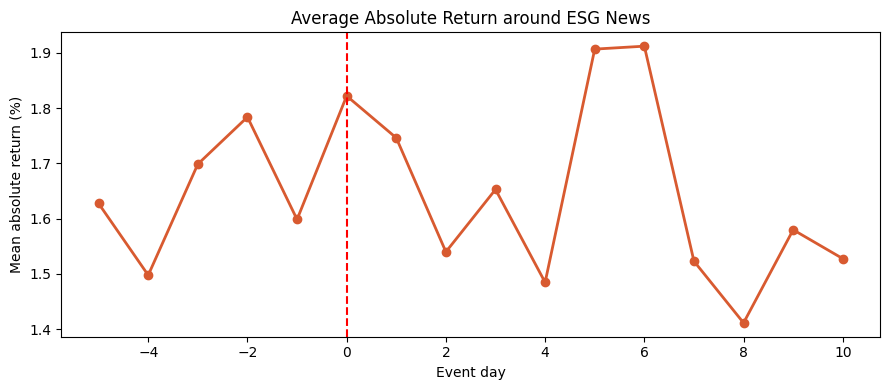

In [ ]:

# ============================================================
# VOLATILITY AROUND ESG EVENTS
# ============================================================

def compute_event_vol_path(company, event_date, event_pre=EVENT_PRE, event_post=EVENT_POST):
    stock_df = price_data.get(company)

    if stock_df is None:
        return None

    ret = stock_df.squeeze().dropna()
    event_date = pd.Timestamp(event_date)

    if event_date not in ret.index:
        future = ret.index[ret.index >= event_date]

        if len(future) == 0:
            return None

        event_date = future[0]

    t0 = ret.index.get_loc(event_date)

    start = t0 - event_pre
    end = t0 + event_post + 1

    if start < 0 or end > len(ret):
        return None

    window = ret.iloc[start:end]

    out = {
        'company': company,
        'event_date': event_date
    }

    for lag, val in zip(range(-event_pre, event_post + 1), window.values):
        out[f'ABSRET_{lag:+d}'] = abs(val) * 100

    return out


vol_paths = []

for idx, row in event_source.dropna(subset=['CAR']).iterrows():
    result = compute_event_vol_path(row['company'], row['Date'])

    if result is not None:
        result['fin_score'] = row['fin_score']
        result['env_score_scaled'] = row['env_score_scaled']
        result['composite_score'] = row['composite_score']
        result['sentiment'] = row['sentiment']
        result['sector'] = row['sector']
        vol_paths.append(result)

vol_path_df = pd.DataFrame(vol_paths)

absret_cols = [f'ABSRET_{lag:+d}' for lag in range(-EVENT_PRE, EVENT_POST + 1)]

mean_absret = vol_path_df[absret_cols].mean()

plt.figure(figsize=(9, 4))
plt.plot(lags, mean_absret.values, marker='o', lw=2, color='#D85A30')
plt.axvline(0, color='red', linestyle='--')
plt.title('Average Absolute Return around ESG News')
plt.xlabel('Event day')
plt.ylabel('Mean absolute return (%)')
plt.tight_layout()
plt.show()

In [ ]:
#Test post-event volatility

from scipy.stats import ttest_rel, wilcoxon

pre_cols = [f'ABSRET_{lag:+d}' for lag in range(-5, 0)]
post_0_5_cols = [f'ABSRET_{lag:+d}' for lag in range(0, 6)]
post_0_10_cols = [f'ABSRET_{lag:+d}' for lag in range(0, 11)]

vol_path_df['absret_pre_5'] = vol_path_df[pre_cols].mean(axis=1)
vol_path_df['absret_post_0_5'] = vol_path_df[post_0_5_cols].mean(axis=1)
vol_path_df['absret_post_0_10'] = vol_path_df[post_0_10_cols].mean(axis=1)

for col in ['absret_post_0_5', 'absret_post_0_10']:
    diff = vol_path_df[col] - vol_path_df['absret_pre_5']

    t_stat, p_val = ttest_rel(vol_path_df[col], vol_path_df['absret_pre_5'])
    w_stat, w_p = wilcoxon(diff)

    print(f"\nPost window: {col}")
    print(f"Pre mean       : {vol_path_df['absret_pre_5'].mean():.4f}%")
    print(f"Post mean      : {vol_path_df[col].mean():.4f}%")
    print(f"Mean difference: {diff.mean():.4f}%")
    print(f"Paired t-test  : t={t_stat:.4f}, p={p_val:.4f}")
    print(f"Wilcoxon test  : W={w_stat:.4f}, p={w_p:.4f}")


Post window: absret_post_0_5
Pre mean       : 1.6412%
Post mean      : 1.6920%
Mean difference: 0.0508%
Paired t-test  : t=0.5699, p=0.5694
Wilcoxon test  : W=10979.0000, p=0.3049

Post window: absret_post_0_10
Pre mean       : 1.6412%
Post mean      : 1.6460%
Mean difference: 0.0048%
Paired t-test  : t=0.0554, p=0.9558
Wilcoxon test  : W=11151.0000, p=0.4001


In [ ]:

# Reload CAR-enriched data only when this section is run independently.
# If the earlier cells ran in this session, keep the in-memory dataframe.
if 'df_esg' not in globals() or 'CAR' not in df_esg.columns:
    df_esg = pd.read_csv('/content/drive/MyDrive/esg_with_CAR.csv')

df_esg['Date'] = pd.to_datetime(df_esg['Date'])
if 'env_score_scaled' not in df_esg.columns:
    df_esg['env_score_scaled'] = 2 * df_esg['env_score'] - 1


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/esg_with_CAR.csv'

In [ ]:

# -- Build daily sentiment time series per company ------------------------------
# Aggregate multiple same-day headlines by mean score. The LSTM uses signed
# environmental materiality (env_score_scaled), not the unsigned raw cosine score.

daily_sent = (df_esg
              .groupby(['company', 'Date'])[['fin_score','env_score_scaled']]
              .mean()
              .reset_index())
daily_sent['Date'] = pd.to_datetime(daily_sent['Date'])
daily_sent = daily_sent.set_index('Date')

print("Daily sentiment series head:")
print(daily_sent.head(6))


Daily sentiment series head:
           company  fin_score  env_score_scaled
Date                                           
2022-01-21   ADANI   0.794220         -0.859857
2022-02-13   ADANI   0.611175         -0.925881
2022-03-04   ADANI   0.221938         -0.259340
2022-04-13   ADANI   0.454394         -0.696397
2022-05-28   ADANI   0.278480         -0.417247
2022-06-14   ADANI   0.114714         -0.635686


In [ ]:
print(daily_sent.columns)
print(daily_sent.head())

Index(['company', 'fin_score', 'env_score_scaled'], dtype='object')
           company  fin_score  env_score_scaled
Date                                           
2022-01-21   ADANI   0.794220         -0.859857
2022-02-13   ADANI   0.611175         -0.925881
2022-03-04   ADANI   0.221938         -0.259340
2022-04-13   ADANI   0.454394         -0.696397
2022-05-28   ADANI   0.278480         -0.417247


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

FEATURE_NAMES = ['return', 'vol_raw', 'fin_score', 'env_score_scaled']
ESG_DECAY_DAYS = 5

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

def build_lstm_dataset(company, seq_len=30, forward_vol_days=5, decay_days=ESG_DECAY_DAYS):
    px = price_data.get(company)
    if px is None or len(px) < seq_len + forward_vol_days + 10:
        return None, None, None, None, None, None, None

    px = px.copy()
    px = px.iloc[:, 0].to_frame(name='return')
    px['vol_raw'] = px['return'].rolling(5).std()

    sent = daily_sent[daily_sent['company'] == company][
        ['fin_score', 'env_score_scaled']
    ].copy()

    merged = px.join(sent, how='left')

    for col in ['fin_score', 'env_score_scaled']:
        event_signal = merged[col].copy()
        decayed = pd.Series(0.0, index=merged.index)

        for lag in range(decay_days):
            decayed = decayed.add(
                event_signal.shift(lag).fillna(0.0) * (0.5 ** lag),
                fill_value=0.0
            )

        merged[col] = decayed

    merged['fwd_vol'] = (
        merged['return']
        .rolling(forward_vol_days)
        .std()
        .shift(-forward_vol_days)
    )

    merged = merged.replace([np.inf, -np.inf], np.nan).dropna()

    if len(merged) < seq_len + forward_vol_days + 60:
        return None, None, None, None, None, None, None

    n = len(merged)
    train_end = int(n * TRAIN_RATIO)
    val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

    scaler = MinMaxScaler()
    scaler.fit(merged[FEATURE_NAMES].iloc[:train_end].values)

    scaled_all = scaler.transform(merged[FEATURE_NAMES].values)
    targets = merged['fwd_vol'].values

    X_tr, y_tr = [], []
    X_val, y_val = [], []
    X_te, y_te, d_te = [], [], []

    for i in range(seq_len, n):
        x_i = scaled_all[i - seq_len:i]
        y_i = targets[i]

        if i + forward_vol_days < train_end:
            X_tr.append(x_i)
            y_tr.append(y_i)

        elif train_end <= i and i + forward_vol_days < val_end:
            X_val.append(x_i)
            y_val.append(y_i)

        elif i >= val_end:
            X_te.append(x_i)
            y_te.append(y_i)
            d_te.append(merged.index[i])

    if len(X_tr) < 40 or len(X_val) < 10 or len(X_te) < 10:
        return None, None, None, None, None, None, None

    return (
        np.array(X_tr, dtype=np.float32),
        np.array(y_tr, dtype=np.float32),
        np.array(X_val, dtype=np.float32),
        np.array(y_val, dtype=np.float32),
        np.array(X_te, dtype=np.float32),
        np.array(y_te, dtype=np.float32),
        d_te,
    )

result = build_lstm_dataset('NTPC')

if result[0] is not None:
    X_tr, y_tr, X_val, y_val, X_te, y_te, d_te = result
    print(f"NTPC — X_train: {X_tr.shape}  X_val: {X_val.shape}  X_test: {X_te.shape}")
    print(f"Split: {TRAIN_RATIO:.0%} train / {VAL_RATIO:.0%} validation / {TEST_RATIO:.0%} test")
    print(f"Features: {FEATURE_NAMES}")
else:
    print("Insufficient data for NTPC")

NTPC — X_train: (664, 30, 4)  X_val: (145, 30, 4)  X_test: (150, 30, 4)
Split: 70% train / 15% validation / 15% test
Features: ['return', 'vol_raw', 'fin_score', 'env_score_scaled']


In [ ]:
# ── LSTM Model Definition ─────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class ESGVolatilityLSTM(nn.Module):
    """
    2-layer LSTM for ESG-driven volatility prediction.
    Input:  (batch, seq_len, n_features)
    Output: (batch, 1) — predicted forward realised volatility
    """
    def __init__(self, n_features=5, hidden_size=16, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq, features)
        lstm_out, _ = self.lstm(x)          # (batch, seq, hidden)
        last_hidden  = lstm_out[:, -1, :]   # take final time step
        out = self.dropout(last_hidden)
        return self.fc(out).squeeze(-1)

# Quick sanity check
dummy = torch.randn(8, 30, 5)
m = ESGVolatilityLSTM()
print("Model output shape:", m(dummy).shape)   # expect torch.Size([8])
print(m)


Model output shape: torch.Size([8])
ESGVolatilityLSTM(
  (lstm): LSTM(5, 16, batch_first=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr

def _eval_predictions(y_true, preds):
    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2 = r2_score(y_true, preds)

    corr = (
        pearsonr(y_true, preds)[0]
        if np.std(y_true) > 0 and np.std(preds) > 0
        else np.nan
    )

    direction_acc = (
        np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(preds)))
        if len(y_true) > 1
        else np.nan
    )

    return mae, rmse, corr, r2, direction_acc


def train_lstm(company, seq_len=30, epochs=100, lr=1e-3,
               batch_size=32, patience=12, esg_features=True):

    result = build_lstm_dataset(company, seq_len=seq_len)

    if result[0] is None:
        print(f"  {company}: insufficient data, skipping.")
        return None, None, None

    X_tr, y_tr, X_val, y_val, X_te, y_te, _ = result

    if not esg_features:
        X_tr = X_tr[:, :, :2]
        X_val = X_val[:, :, :2]
        X_te = X_te[:, :, :2]

    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    model = ESGVolatilityLSTM(n_features=X_tr.shape[2]).to(device)
    optim = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr)),
        batch_size=batch_size,
        shuffle=False
    )

    X_val_t = torch.tensor(X_val).to(device)
    y_val_t = torch.tensor(y_val).to(device)

    train_losses = []
    val_losses = []

    best_val = float('inf')
    best_state = None
    patience_ctr = 0

    for ep in range(epochs):
        model.train()
        ep_loss = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optim.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optim.step()
            ep_loss += loss.item()

        avg_train_loss = ep_loss / max(len(train_loader), 1)
        train_losses.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t), y_val_t).item()

        val_losses.append(val_loss)

        if val_loss < best_val - 1e-7:
            best_val = val_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            patience_ctr = 0
        else:
            patience_ctr += 1

            if patience_ctr >= patience:
                print(f"  {company}: early stop at epoch {ep + 1} | best val loss={best_val:.6f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    model.eval()

    with torch.no_grad():
        val_preds = model(torch.tensor(X_val).to(device)).cpu().numpy()
        test_preds = model(torch.tensor(X_te).to(device)).cpu().numpy()

    val_mae, val_rmse, val_corr, val_r2, val_dir = _eval_predictions(y_val, val_preds)
    mae, rmse, corr, r2, direction_acc = _eval_predictions(y_te, test_preds)

    tag = "ESG" if esg_features else "Baseline"

    print(
        f"  {company:12s} [{tag}] | "
        f"VAL_RMSE={val_rmse:.5f}  TEST_RMSE={rmse:.5f}  "
        f"TEST_MAE={mae:.5f}  r={corr:.3f}  R2={r2:.3f}  DirAcc={direction_acc:.3f}"
    )

    return model, {
        'mae': mae,
        'rmse': rmse,
        'corr': corr,
        'r2': r2,
        'direction_acc': direction_acc,
        'val_mae': val_mae,
        'val_rmse': val_rmse,
        'val_corr': val_corr,
        'val_r2': val_r2,
        'val_direction_acc': val_dir,
        'train_losses': train_losses,
        'val_losses': val_losses,
    }, torch.tensor(X_te)


print("Training LSTM models (reduced)— full ESG model...")
print("-" * 85)

lstm_models = {}
lstm_metrics = {}
lstm_X_test = {}

for company in TICKER_MAP:
    model, metrics, X_te = train_lstm(company, esg_features=True)

    if model is not None:
        lstm_models[company] = model
        lstm_metrics[company] = metrics
        lstm_X_test[company] = X_te


print("\nTraining LSTM models (reduced)— price-only baseline...")
print("-" * 85)

lstm_baseline = {}

for company in TICKER_MAP:
    model_b, metrics_b, _ = train_lstm(company, esg_features=False)

    if model_b is not None:
        lstm_baseline[company] = metrics_b

print("\nDone.")

Training LSTM models (reduced)— full ESG model...
-------------------------------------------------------------------------------------
  RELIANCE: early stop at epoch 25 | best val loss=0.000082
  RELIANCE     [ESG] | VAL_RMSE=0.00907  TEST_RMSE=0.00685  TEST_MAE=0.00576  r=-0.117  R2=-0.509  DirAcc=0.443
  ADANI: early stop at epoch 28 | best val loss=0.000406
  ADANI        [ESG] | VAL_RMSE=0.02014  TEST_RMSE=0.02337  TEST_MAE=0.01460  r=0.400  R2=-0.039  DirAcc=0.517
  TATA POWER: early stop at epoch 13 | best val loss=0.000193
  TATA POWER   [ESG] | VAL_RMSE=0.01388  TEST_RMSE=0.00724  TEST_MAE=0.00555  r=-0.017  R2=-0.030  DirAcc=0.490
  NTPC: early stop at epoch 43 | best val loss=0.000246
  NTPC         [ESG] | VAL_RMSE=0.01569  TEST_RMSE=0.00679  TEST_MAE=0.00524  r=0.251  R2=0.020  DirAcc=0.450
  ONGC: early stop at epoch 15 | best val loss=0.000295
  ONGC         [ESG] | VAL_RMSE=0.01718  TEST_RMSE=0.00912  TEST_MAE=0.00696  r=-0.278  R2=-0.198  DirAcc=0.470
  JSW: early sto


LSTM Performance — Full ESG Model (held-out test set)
               mae    rmse    corr      r2  direction_acc  val_rmse
RELIANCE    0.0058  0.0069 -0.1171 -0.5095         0.4430    0.0091
ADANI       0.0146  0.0234  0.4001 -0.0388         0.5168    0.0201
TATA POWER  0.0055  0.0072 -0.0166 -0.0296         0.4899    0.0139
NTPC        0.0052  0.0068  0.2510  0.0200         0.4497    0.0157
ONGC        0.0070  0.0091 -0.2783 -0.1976         0.4698    0.0172
JSW         0.0102  0.0123 -0.1493 -0.2078         0.4899    0.0169
NHPC        0.0070  0.0095 -0.1113 -0.1847         0.5235    0.0144
POWER GRID  0.0044  0.0057  0.0871 -0.0703         0.4966    0.0131
BPCL        0.0057  0.0072  0.0263 -0.2211         0.4966    0.0134
GAIL        0.0066  0.0079  0.1274 -0.2066         0.4228    0.0199
IOCL        0.0065  0.0082 -0.1107 -0.4741         0.4966    0.0148

Mean TEST metrics:
mae              0.0071
rmse             0.0095
corr             0.0099
r2              -0.1927
direction_acc

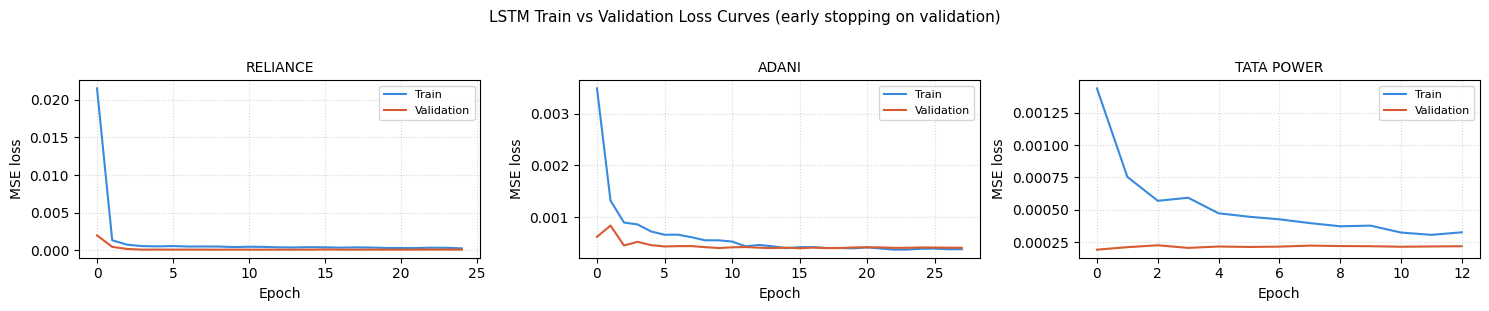

In [ ]:
metrics_df = pd.DataFrame({
    k: {
        m: v
        for m, v in vals.items()
        if m not in ['train_losses', 'val_losses']
    }
    for k, vals in lstm_metrics.items()
}).T

print("\nLSTM Performance — Full ESG Model (held-out test set)")
print("=" * 70)

cols_to_show = [
    'mae',
    'rmse',
    'corr',
    'r2',
    'direction_acc',
    'val_rmse'
]

print(metrics_df[cols_to_show].round(4))

if not metrics_df.empty:
    print("\nMean TEST metrics:")
    print(
        metrics_df[['mae', 'rmse', 'corr', 'r2', 'direction_acc']]
        .mean(numeric_only=True)
        .round(4)
        .to_string()
    )


abl = pd.DataFrame()

if lstm_baseline:
    rows = []

    for co in lstm_metrics:
        if co in lstm_baseline:
            rows.append({
                'Company': co,
                'MAE_ESG': lstm_metrics[co]['mae'],
                'MAE_Baseline': lstm_baseline[co]['mae'],
                'Delta_MAE': lstm_baseline[co]['mae'] - lstm_metrics[co]['mae'],
                'RMSE_ESG': lstm_metrics[co]['rmse'],
                'RMSE_Baseline': lstm_baseline[co]['rmse'],
                'Delta_RMSE': lstm_baseline[co]['rmse'] - lstm_metrics[co]['rmse'],
                'Improvement': (
                    'YES'
                    if lstm_metrics[co]['rmse'] < lstm_baseline[co]['rmse']
                    else 'NO'
                )
            })

    abl = pd.DataFrame(rows)

    print("\nAblation: ESG model vs price-only baseline (held-out test set)")
    print("Positive deltas mean the ESG model improves over baseline.")
    print(abl.round(5).to_string(index=False))

    print(f"\nMean Delta_MAE : {abl['Delta_MAE'].mean():.5f}")
    print(f"Mean Delta_RMSE: {abl['Delta_RMSE'].mean():.5f}")
    print(f"RMSE improved companies: {(abl['Delta_RMSE'] > 0).sum()} / {len(abl)}")


companies_to_plot = list(lstm_metrics.keys())[:3]

if companies_to_plot:
    fig, axes = plt.subplots(
        1,
        len(companies_to_plot),
        figsize=(5 * len(companies_to_plot), 3),
        sharey=False
    )

    if len(companies_to_plot) == 1:
        axes = [axes]

    for ax, co in zip(axes, companies_to_plot):
        train_losses = lstm_metrics[co].get('train_losses', [])
        val_losses = lstm_metrics[co].get('val_losses', [])

        ax.plot(train_losses, color='#378ADD', lw=1.5, label='Train')
        ax.plot(val_losses, color='#D85A30', lw=1.5, label='Validation')

        ax.set_title(co, fontsize=10)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE loss')
        ax.grid(True, linestyle=':', alpha=0.5)
        ax.legend(fontsize=8)

    plt.suptitle(
        'LSTM Train vs Validation Loss Curves (early stopping on validation)',
        fontsize=11,
        y=1.02
    )

    plt.tight_layout()

    os.makedirs('/content/drive/MyDrive/SHAP_outputs/', exist_ok=True)

    plt.savefig(
        '/content/drive/MyDrive/SHAP_outputs/LSTM(strict)_train_val_loss_curves_7-15-15.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

### LAGGED CORRELATION

In [ ]:
# ============================================================
# LAGGED CORRELATION + DISTRIBUTED LAG ANALYSIS
# ESG_t vs future return / absolute return / volatility
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import pearsonr, spearmanr

MAX_FWD_LAG = 10
MAX_ESG_LAG = 10

# ------------------------------------------------------------
# 1. Build daily company panel
# ------------------------------------------------------------

daily_panel_list = []

for company in TICKER_MAP:
    px = price_data.get(company)

    if px is None:
        continue

    ret = px.squeeze().dropna().to_frame(name='return')
    ret.index = pd.to_datetime(ret.index)
    ret['company'] = company

    # Daily ESG signal
    sent = daily_sent[daily_sent['company'] == company][
        ['fin_score', 'env_score_scaled']
    ].copy()

    sent.index = pd.to_datetime(sent.index)

    merged = ret.join(sent, how='left')

    # No-news days get zero ESG signal
    merged[['fin_score', 'env_score_scaled']] = (
        merged[['fin_score', 'env_score_scaled']]
        .fillna(0.0)
    )

    merged['composite_score'] = (
        0.6 * merged['fin_score'] +
        0.4 * merged['env_score_scaled']
    )

    # News intensity features
    news_counts = (
        df_esg[df_esg['company'] == company]
        .groupby('Date')
        .size()
        .rename('news_count')
    )

    news_counts.index = pd.to_datetime(news_counts.index)

    merged = merged.join(news_counts, how='left')
    merged['news_count'] = merged['news_count'].fillna(0.0)

    # Stock behaviour variables
    merged['abs_return'] = merged['return'].abs()
    merged['vol_5d'] = merged['return'].rolling(5).std()
    merged['vol_10d'] = merged['return'].rolling(10).std()

    # Optional signed negative-news intensity
    merged['neg_fin_score'] = merged['fin_score'].clip(upper=0).abs()
    merged['pos_fin_score'] = merged['fin_score'].clip(lower=0)

    daily_panel_list.append(
        merged.reset_index().rename(columns={'index': 'Date'})
    )

daily_panel = pd.concat(daily_panel_list, ignore_index=True)
daily_panel = daily_panel.sort_values(['company', 'Date']).reset_index(drop=True)

print("Daily panel shape:", daily_panel.shape)
print(daily_panel.head())

Daily panel shape: (11088, 12)
        Date    return company  fin_score  env_score_scaled  composite_score  \
0 2021-06-02  0.022619   ADANI        0.0               0.0              0.0   
1 2021-06-03 -0.009925   ADANI        0.0               0.0              0.0   
2 2021-06-04 -0.007499   ADANI        0.0               0.0              0.0   
3 2021-06-07 -0.009708   ADANI        0.0               0.0              0.0   
4 2021-06-08  0.002135   ADANI        0.0               0.0              0.0   

   news_count  abs_return    vol_5d  vol_10d  neg_fin_score  pos_fin_score  
0         0.0    0.022619       NaN      NaN            0.0            0.0  
1         0.0    0.009925       NaN      NaN            0.0            0.0  
2         0.0    0.007499       NaN      NaN            0.0            0.0  
3         0.0    0.009708       NaN      NaN            0.0            0.0  
4         0.0    0.002135  0.013821      NaN            0.0            0.0  


In [ ]:
print("Total company-days:", len(daily_panel))
print("News days:", (daily_panel['news_count'] > 0).sum())
print("News-day share:", (daily_panel['news_count'] > 0).mean())

print("\nNews days by company:")
print(
    daily_panel[daily_panel['news_count'] > 0]
    .groupby('company')
    .size()
    .sort_values(ascending=False)
)

Total company-days: 11088
News days: 257
News-day share: 0.02317821067821068

News days by company:
company
TATA POWER    68
NTPC          56
ADANI         53
JSW           20
RELIANCE      18
NHPC          13
ONGC          11
BPCL           9
GAIL           6
IOCL           2
POWER GRID     1
dtype: int64


In [ ]:

# ============================================================
# 2. Lagged correlation: ESG today vs future stock behaviour
# ============================================================

lag_rows = []

for k in range(0, MAX_FWD_LAG + 1):
    temp = daily_panel.copy()

    temp[f'return_fwd_{k}'] = temp.groupby('company')['return'].shift(-k)
    temp[f'absret_fwd_{k}'] = temp.groupby('company')['abs_return'].shift(-k)
    temp[f'vol5_fwd_{k}'] = temp.groupby('company')['vol_5d'].shift(-k)

    valid = temp.dropna(subset=[
        'composite_score',
        'fin_score',
        'env_score_scaled',
        f'return_fwd_{k}',
        f'absret_fwd_{k}',
        f'vol5_fwd_{k}'
    ])

    def safe_corr(x, y, method='pearson'):
        if len(x) < 5 or np.std(x) == 0 or np.std(y) == 0:
            return np.nan, np.nan

        if method == 'spearman':
            r, p = spearmanr(x, y)
        else:
            r, p = pearsonr(x, y)

        return r, p

    r_ret, p_ret = safe_corr(valid['composite_score'], valid[f'return_fwd_{k}'])
    r_abs, p_abs = safe_corr(valid['composite_score'], valid[f'absret_fwd_{k}'])
    r_vol, p_vol = safe_corr(valid['composite_score'], valid[f'vol5_fwd_{k}'])

    sr_ret, sp_ret = safe_corr(valid['composite_score'], valid[f'return_fwd_{k}'], method='spearman')
    sr_abs, sp_abs = safe_corr(valid['composite_score'], valid[f'absret_fwd_{k}'], method='spearman')
    sr_vol, sp_vol = safe_corr(valid['composite_score'], valid[f'vol5_fwd_{k}'], method='spearman')

    lag_rows.append({
        'future_lag_days': k,
        'N': len(valid),

        'pearson_esg_return': r_ret,
        'p_return': p_ret,

        'pearson_esg_absret': r_abs,
        'p_absret': p_abs,

        'pearson_esg_vol5': r_vol,
        'p_vol5': p_vol,

        'spearman_esg_return': sr_ret,
        'spearman_p_return': sp_ret,

        'spearman_esg_absret': sr_abs,
        'spearman_p_absret': sp_abs,

        'spearman_esg_vol5': sr_vol,
        'spearman_p_vol5': sp_vol,
    })

lag_corr_df = pd.DataFrame(lag_rows)

print("Lagged correlation: ESG_t vs future stock behaviour")
print(lag_corr_df.round(4).to_string(index=False))

Lagged correlation: ESG_t vs future stock behaviour
 future_lag_days     N  pearson_esg_return  p_return  pearson_esg_absret  p_absret  pearson_esg_vol5  p_vol5  spearman_esg_return  spearman_p_return  spearman_esg_absret  spearman_p_absret  spearman_esg_vol5  spearman_p_vol5
               0 11044              0.0235    0.0137              0.0177    0.0627           -0.0017  0.8581              -0.0088             0.3561               0.0045             0.6392            -0.0017           0.8548
               1 11044              0.0114    0.2299             -0.0012    0.9016           -0.0097  0.3086              -0.0002             0.9811               0.0046             0.6259            -0.0062           0.5171
               2 11044              0.0172    0.0708             -0.0076    0.4245           -0.0133  0.1615               0.0123             0.1952              -0.0108             0.2567            -0.0017           0.8619
               3 11044             -0.0028    0.

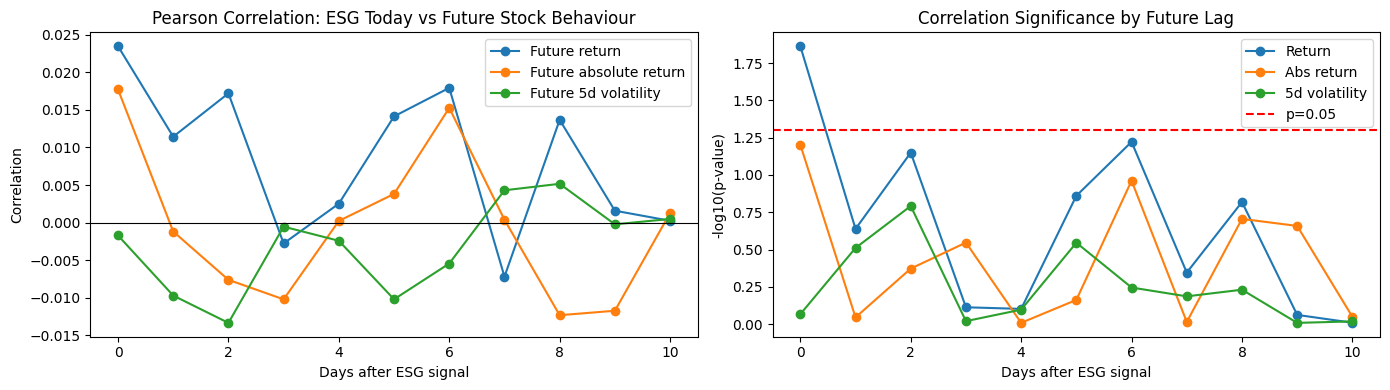

In [ ]:
# ============================================================
# 3. Plot lagged correlations
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(
    lag_corr_df['future_lag_days'],
    lag_corr_df['pearson_esg_return'],
    marker='o',
    label='Future return'
)

axes[0].plot(
    lag_corr_df['future_lag_days'],
    lag_corr_df['pearson_esg_absret'],
    marker='o',
    label='Future absolute return'
)

axes[0].plot(
    lag_corr_df['future_lag_days'],
    lag_corr_df['pearson_esg_vol5'],
    marker='o',
    label='Future 5d volatility'
)

axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('Pearson Correlation: ESG Today vs Future Stock Behaviour')
axes[0].set_xlabel('Days after ESG signal')
axes[0].set_ylabel('Correlation')
axes[0].legend()

axes[1].plot(
    lag_corr_df['future_lag_days'],
    -np.log10(lag_corr_df['p_return']),
    marker='o',
    label='Return'
)

axes[1].plot(
    lag_corr_df['future_lag_days'],
    -np.log10(lag_corr_df['p_absret']),
    marker='o',
    label='Abs return'
)

axes[1].plot(
    lag_corr_df['future_lag_days'],
    -np.log10(lag_corr_df['p_vol5']),
    marker='o',
    label='5d volatility'
)

axes[1].axhline(-np.log10(0.05), color='red', linestyle='--', label='p=0.05')
axes[1].set_title('Correlation Significance by Future Lag')
axes[1].set_xlabel('Days after ESG signal')
axes[1].set_ylabel('-log10(p-value)')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SHAP_outputs/lagged_correlation_esg(strict)_stock.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 4. Distributed lag regression
# ESG lags predicting next-day return / abs return / volatility
# ============================================================

panel = daily_panel.sort_values(['company', 'Date']).copy()

# Create ESG lag variables
for lag in range(0, MAX_ESG_LAG + 1):
    panel[f'esg_lag_{lag}'] = panel.groupby('company')['composite_score'].shift(lag)
    panel[f'fin_lag_{lag}'] = panel.groupby('company')['fin_score'].shift(lag)
    panel[f'env_lag_{lag}'] = panel.groupby('company')['env_score_scaled'].shift(lag)
    panel[f'news_count_lag_{lag}'] = panel.groupby('company')['news_count'].shift(lag)

# Targets
panel['return_next'] = panel.groupby('company')['return'].shift(-1)
panel['absret_next'] = panel.groupby('company')['abs_return'].shift(-1)
panel['vol5_next'] = panel.groupby('company')['vol_5d'].shift(-1)

# Controls
panel['return_lag_1'] = panel.groupby('company')['return'].shift(1)
panel['vol5_lag_1'] = panel.groupby('company')['vol_5d'].shift(1)
panel['vol10_lag_1'] = panel.groupby('company')['vol_10d'].shift(1)

esg_lag_cols = [f'esg_lag_{lag}' for lag in range(0, MAX_ESG_LAG + 1)]

reg_cols = (
    esg_lag_cols +
    [
        'return_next',
        'absret_next',
        'vol5_next',
        'return_lag_1',
        'vol5_lag_1',
        'vol10_lag_1',
        'company'
    ]
)

panel_reg = panel.replace([np.inf, -np.inf], np.nan).dropna(subset=reg_cols).copy()

print("Distributed lag regression sample:", panel_reg.shape)
print("Companies:", panel_reg['company'].nunique())

Distributed lag regression sample: (10967, 62)
Companies: 11


In [ ]:
# ============================================================
# 5. Run distributed lag regressions with company fixed effects
# ============================================================

lag_formula = ' + '.join(esg_lag_cols)

formula_return = (
    f'return_next ~ {lag_formula} + return_lag_1 + vol5_lag_1 + C(company)'
)

formula_absret = (
    f'absret_next ~ {lag_formula} + return_lag_1 + vol5_lag_1 + C(company)'
)

formula_vol = (
    f'vol5_next ~ {lag_formula} + return_lag_1 + vol5_lag_1 + vol10_lag_1 + C(company)'
)

m_lag_return = smf.ols(formula_return, data=panel_reg).fit(
    cov_type='cluster',
    cov_kwds={'groups': panel_reg['company']}
)

m_lag_absret = smf.ols(formula_absret, data=panel_reg).fit(
    cov_type='cluster',
    cov_kwds={'groups': panel_reg['company']}
)

m_lag_vol = smf.ols(formula_vol, data=panel_reg).fit(
    cov_type='cluster',
    cov_kwds={'groups': panel_reg['company']}
)

print("\nDistributed Lag Model: next-day return")
print(m_lag_return.summary().tables[1])
print(f"R² = {m_lag_return.rsquared:.4f}")

print("\nDistributed Lag Model: next-day absolute return")
print(m_lag_absret.summary().tables[1])
print(f"R² = {m_lag_absret.rsquared:.4f}")

print("\nDistributed Lag Model: next-day 5-day volatility")
print(m_lag_vol.summary().tables[1])
print(f"R² = {m_lag_vol.rsquared:.4f}")


Distributed Lag Model: next-day return
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   -0.0006      0.001     -0.577      0.564      -0.002       0.001
C(company)[T.BPCL]           0.0007      0.000      1.763      0.078   -7.85e-05       0.001
C(company)[T.GAIL]           0.0009      0.000      2.655      0.008       0.000       0.002
C(company)[T.IOCL]           0.0010      0.000      2.509      0.012       0.000       0.002
C(company)[T.JSW]            0.0012    3.4e-05     34.052      0.000       0.001       0.001
C(company)[T.NHPC]           0.0014      0.000      5.295      0.000       0.001       0.002
C(company)[T.NTPC]           0.0012      0.000      2.509      0.012       0.000       0.002
C(company)[T.ONGC]           0.0010      0.000      2.939      0.003       0.000       0.002
C(company)[T.POWER GRID]     0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 23, but rank is 10
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 23, but rank is 10
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 24, but rank is 10
  warnings.warn('covariance of constraints does not have full '


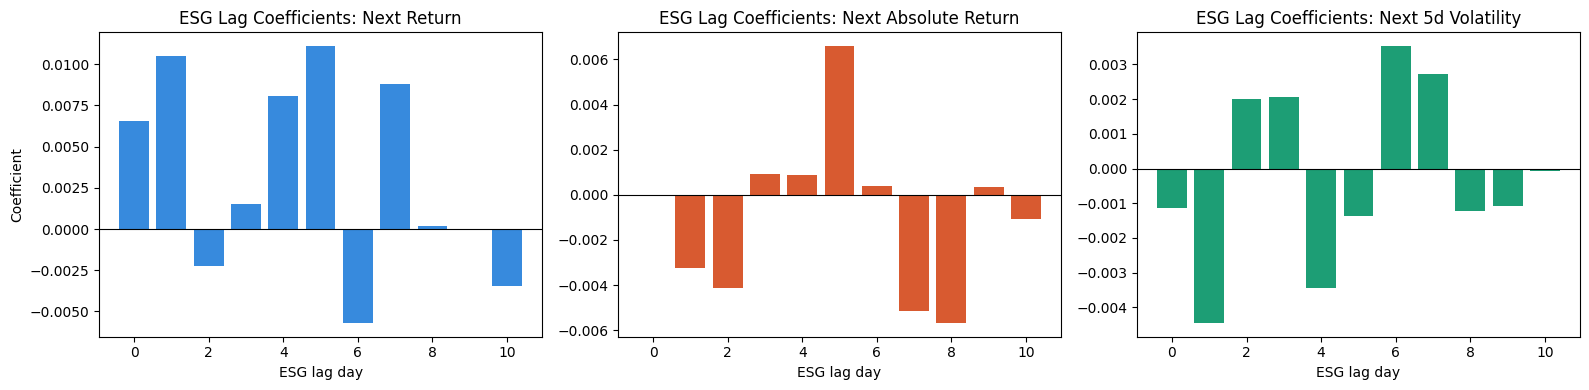

Distributed lag coefficient table:
 lag  return_coef  return_p  absret_coef  absret_p  vol_coef    vol_p
   0     0.006527  0.354680    -0.000072  0.990705 -0.001143 0.384541
   1     0.010503  0.138408    -0.003241  0.361199 -0.004447 0.121735
   2    -0.002239  0.270944    -0.004123  0.075180  0.001994 0.607123
   3     0.001526  0.656769     0.000907  0.719014  0.002055 0.690183
   4     0.008063  0.001841     0.000860  0.740943 -0.003442 0.153422
   5     0.011094  0.197026     0.006591  0.018241 -0.001378 0.594870
   6    -0.005696  0.508917     0.000397  0.938386  0.003527 0.047088
   7     0.008818  0.059692    -0.005136  0.172114  0.002723 0.396036
   8     0.000164  0.975442    -0.005680  0.083480 -0.001223 0.450200
   9    -0.000057  0.990307     0.000355  0.942288 -0.001086 0.578169
  10    -0.003479  0.497570    -0.001075  0.764237 -0.000066 0.975330


In [ ]:
# ============================================================
# 6. Plot distributed lag coefficients
# ============================================================

coef_rows = []

for lag in range(0, MAX_ESG_LAG + 1):
    name = f'esg_lag_{lag}'

    coef_rows.append({
        'lag': lag,

        'return_coef': m_lag_return.params.get(name, np.nan),
        'return_p': m_lag_return.pvalues.get(name, np.nan),

        'absret_coef': m_lag_absret.params.get(name, np.nan),
        'absret_p': m_lag_absret.pvalues.get(name, np.nan),

        'vol_coef': m_lag_vol.params.get(name, np.nan),
        'vol_p': m_lag_vol.pvalues.get(name, np.nan),
    })

lag_coef_df = pd.DataFrame(coef_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(lag_coef_df['lag'], lag_coef_df['return_coef'], color='#378ADD')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('ESG Lag Coefficients: Next Return')
axes[0].set_xlabel('ESG lag day')
axes[0].set_ylabel('Coefficient')

axes[1].bar(lag_coef_df['lag'], lag_coef_df['absret_coef'], color='#D85A30')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('ESG Lag Coefficients: Next Absolute Return')
axes[1].set_xlabel('ESG lag day')

axes[2].bar(lag_coef_df['lag'], lag_coef_df['vol_coef'], color='#1D9E75')
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_title('ESG Lag Coefficients: Next 5d Volatility')
axes[2].set_xlabel('ESG lag day')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SHAP_outputs/distributed_lag_coefficients(strict).png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Distributed lag coefficient table:")
print(lag_coef_df.round(6).to_string(index=False))

In [ ]:
# ============================================================
# 7. Save lagged analysis outputs
# ============================================================

lag_corr_df.to_csv('/content/drive/MyDrive/lagged_correlation_results.csv', index=False)
lag_coef_df.to_csv('/content/drive/MyDrive/distributed_lag_coefficients.csv', index=False)
panel_reg.to_csv('/content/drive/MyDrive/daily_panel_for_lag_regression.csv', index=False)

print("Saved:")
print("- lagged_correlation_results.csv")
print("- distributed_lag_coefficients.csv")
print("- daily_panel_for_lag_regression.csv")

Saved:
- lagged_correlation_results.csv
- distributed_lag_coefficients.csv
- daily_panel_for_lag_regression.csv


In [ ]:
df_esg.sentiment.value_counts()

,count
sentiment,
Neutral,159
Positive,152
Negative,7


## Section 5 — SHAP Explainability
Three levels of explanation:

| Level | What it explains | SHAP method |
|-------|-----------------|-------------|
| **Token-level** (FinBERT) | Which *words* drove financial sentiment | `shap.Explainer` (text masker) |
| **Sentence-level** (SBERT) | Which *words* drove env. materiality score | Custom `nlp_weighted_predict` + text masker |
| **Feature-level** (LSTM) | Which *input feature* and *lag-day* drove volatility prediction | `shap.DeepExplainer` or `GradientExplainer` |

RQ3 is answered by comparing token SHAP salience between the FinBERT and SBERT models.

**Reference:** Lundberg & Lee (2017) — "A Unified Approach to Interpreting Model Predictions"


In [ ]:
# ============================================================
# SHAP EXPLAINABILITY: ENERGY-RELEVANT, IMPACT-BASED
# FinBERT + Environmental Model
# ============================================================

import os
import re
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

shap.initjs()

SHAP_OUT_DIR = '/content/drive/MyDrive/SHAP_outputs/'
os.makedirs(SHAP_OUT_DIR, exist_ok=True)

N_SHAP_SAMPLES = 30
TOP_TOKENS = 15

print("SHAP output directory:", SHAP_OUT_DIR)

SHAP output directory: /content/drive/MyDrive/SHAP_outputs/


In [ ]:
# ============================================================
# Build SHAP explainer for FinBERT
# ============================================================

task_pipe = pipeline(
    'text-classification',
    model=sentiment_pipe.model,
    tokenizer=sentiment_pipe.tokenizer,
    top_k=None
)

masker_fin = shap.maskers.Text(sentiment_pipe.tokenizer)
explainer_fin = shap.Explainer(task_pipe, masker=masker_fin)

print("FinBERT SHAP explainer ready.")

FinBERT SHAP explainer ready.


In [ ]:
# ============================================================
# Load scored ESG data
# ============================================================

df_esg = pd.read_csv('/content/drive/MyDrive/esg_with_CAR.csv')

if 'Date' in df_esg.columns:
    df_esg['Date'] = pd.to_datetime(df_esg['Date'])

print("Loaded df_esg:", df_esg.shape)

Loaded df_esg: (318, 24)


In [ ]:
# ============================================================
# POS / NER setup for SHAP grouping
# Protects proper nouns and named entities from token splitting
# ============================================================

import sys
import subprocess
import spacy

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    subprocess.run(
        [sys.executable, "-m", "spacy", "download", "en_core_web_sm"],
        check=True
    )
    nlp = spacy.load("en_core_web_sm")

print("spaCy POS/NER model loaded.")

spaCy POS/NER model loaded.


In [ ]:
# ============================================================
# Build SHAP explainer for environmental materiality model
# ============================================================

def nlp_env_predict(texts):
    """
    Wrapper for SHAP.

    Returns 3 output channels:
    [negative_placeholder, neutral_placeholder, env_impact]

    env_impact = FinBERT direction x SBERT cosine similarity.
    """
    clean = [str(t) for t in texts]

    fin_results = sentiment_pipe(clean)

    headline_emb = sbert_model.encode(clean, convert_to_tensor=True)
    anchor_emb_ = sbert_model.encode(ENV_ANCHOR, convert_to_tensor=True)
    similarities = util.cos_sim(headline_emb, anchor_emb_).flatten().tolist()

    outputs = []

    for i, res in enumerate(fin_results):
        d = {item['label'].lower(): item['score'] for item in res}

        direction = (
            1.0
            if d.get('positive', 0) > d.get('negative', 0)
            else -1.0
        )

        env_impact = direction * similarities[i]

        outputs.append([0.0, 0.0, env_impact])

    return np.array(outputs)


masker_env = shap.maskers.Text(sentiment_pipe.tokenizer)

explainer_env = shap.Explainer(
    nlp_env_predict,
    masker=masker_env,
    output_names=['negative', 'neutral', 'env_impact']
)

print("Environmental SHAP explainer ready.")

Environmental SHAP explainer ready.


In [ ]:
# ============================================================
# IMPACT-BASED SHAP SAMPLE SELECTION
# Positive CAAR, negative neutral CAAR, volatility-spike events
# ============================================================

import re
import numpy as np
import pandas as pd

N_SHAP_SAMPLES = 30

# ------------------------------------------------------------
# 1. Ensure CAR_0_10 exists in event_path_df
# ------------------------------------------------------------

if 'CAR_0_10' not in event_path_df.columns:
    event_path_df['CAR_0_10'] = event_path_df[
        [f'AR_{lag:+d}' for lag in range(0, 11)]
    ].sum(axis=1)

# Standardize headline column name
if 'Headline' not in event_path_df.columns and 'Headlines' in event_path_df.columns:
    event_path_df['Headline'] = event_path_df['Headlines']

# ------------------------------------------------------------
# 2. Keep only energy-relevant event-path headlines
# ------------------------------------------------------------

ENERGY_KEYWORDS = [
    'energy',
    'power',
    'renewable',
    'solar',
    'wind',
    'hydro',
    'green hydrogen',
    'hydrogen',
    'ev',
    'electric vehicle',
    'charging',
    'battery',
    'biofuel',
    'fuel',
    'oil',
    'gas',
    'coal',
    'electricity',
    'transmission',
    'grid',
    'carbon',
    'emission',
    'emissions',
    'net zero',
    'clean energy',
    'thermal',
]

energy_pattern = '|'.join([re.escape(k) for k in ENERGY_KEYWORDS])

event_energy = event_path_df[
    event_path_df['Headline']
    .astype(str)
    .str.contains(energy_pattern, case=False, na=False)
].copy()

print("Event-path headlines:", len(event_path_df))
print("Energy-relevant event-path headlines:", len(event_energy))

# ------------------------------------------------------------
# 3. Group A: Positive class with strongest positive CAR_0_10
# ------------------------------------------------------------

positive_impact = (
    event_energy[event_energy['sentiment'] == 'Positive']
    .sort_values('CAR_0_10', ascending=False)
    .head(10)
    .copy()
)

positive_impact['shap_group'] = 'positive_high_CAR'

# ------------------------------------------------------------
# 4. Group B: Neutral class with worst negative CAR_0_10
# ------------------------------------------------------------

neutral_negative_impact = (
    event_energy[event_energy['sentiment'] == 'Neutral']
    .sort_values('CAR_0_10', ascending=True)
    .head(10)
    .copy()
)

neutral_negative_impact['shap_group'] = 'neutral_worst_CAR'

# ------------------------------------------------------------
# 5. Group C: Highest post-event volatility / absolute return spike
# ------------------------------------------------------------

vol_event = None

if 'vol_path_df' in globals() and len(vol_path_df) > 0:
    vol_temp = vol_path_df.copy()

    if 'event_date' in vol_temp.columns:
        vol_temp['event_date'] = pd.to_datetime(vol_temp['event_date'])

    event_energy['event_date'] = pd.to_datetime(event_energy['event_date'])

    absret_cols_post = [
        f'ABSRET_{lag:+d}'
        for lag in range(0, 11)
        if f'ABSRET_{lag:+d}' in vol_temp.columns
    ]

    if absret_cols_post:
        vol_temp['post_absret_max_0_10'] = vol_temp[absret_cols_post].max(axis=1)
        vol_temp['post_absret_mean_0_10'] = vol_temp[absret_cols_post].mean(axis=1)

        vol_event = vol_temp.merge(
            event_energy[
                [
                    'company',
                    'event_date',
                    'Headline',
                    'sentiment',
                    'fin_score',
                    'env_score_scaled',
                    'composite_score',
                    'CAR_0_10'
                ]
            ],
            on=['company', 'event_date'],
            how='inner'
        )

        volatility_spikes = (
            vol_event
            .sort_values('post_absret_max_0_10', ascending=False)
            .head(10)
            .copy()
        )

        volatility_spikes['shap_group'] = 'high_volatility_spike'

    else:
        print("No post-event ABSRET columns found in vol_path_df.")
        volatility_spikes = pd.DataFrame()

else:
    print("vol_path_df not found. Skipping volatility-spike SHAP group.")
    volatility_spikes = pd.DataFrame()

# ------------------------------------------------------------
# 6. Combine groups and remove duplicates
# ------------------------------------------------------------

sample_df = pd.concat(
    [
        positive_impact,
        neutral_negative_impact,
        volatility_spikes
    ],
    ignore_index=True
)

sample_df = (
    sample_df
    .drop_duplicates(subset=['company', 'event_date', 'Headline'])
    .head(N_SHAP_SAMPLES)
    .reset_index(drop=True)
)

sample_df['env_audit_score'] = np.nan

print("\nFinal impact-based SHAP sample size:", len(sample_df))

print("\nSHAP group counts:")
print(sample_df['shap_group'].value_counts())

display_cols = [
    'shap_group',
    'company',
    'event_date',
    'sentiment',
    'CAR_0_10',
    'fin_score',
    'env_score_scaled',
    'Headline'
]

extra_cols = [
    c for c in ['post_absret_max_0_10', 'post_absret_mean_0_10']
    if c in sample_df.columns
]

display_cols = display_cols[:-1] + extra_cols + ['Headline']

print("\nSelected SHAP headlines:")
print(sample_df[display_cols].head(30).to_string(index=False))

Event-path headlines: 218
Energy-relevant event-path headlines: 218

Final impact-based SHAP sample size: 25

SHAP group counts:
shap_group
positive_high_CAR        10
neutral_worst_CAR        10
high_volatility_spike     5
Name: count, dtype: int64

Selected SHAP headlines:
           shap_group    company event_date sentiment   CAR_0_10  fin_score  env_score_scaled  post_absret_max_0_10  post_absret_mean_0_10                                                                                                                         Headline
    positive_high_CAR      ADANI 2023-02-24  Positive  49.163348   0.485012         -0.362810                   NaN                    NaN                                                                    Adani group's renewable energy projects approved by Sri Lanka
    positive_high_CAR      ADANI 2023-11-28  Positive  43.285570   0.304249         -0.750712                   NaN                    NaN                                                  

In [ ]:
# ============================================================
# SHAP grouping config: entity/phrase protection
# ============================================================

STOP_UNITS = {
    '', ' ', "'", '"', "'s", 's', '’s', '-', ',', '.', ':', ';',
    '(', ')', '[', ']', '{', '}', '|', '/', '\\'
}

PHRASE_PATTERNS = [
    'green hydrogen',
    'net zero',
    'carbon emissions',
    'carbon emission',
    'renewable energy',
    'solar power',
    'wind power',
    'electric vehicle',
    'ev charging',
    'clean energy',
    'fossil fuel',
    'power purchase',
    'green bond',
    'climate change',
    'sustainable energy',
    'energy transition',
    'charging stations',
    'solar project',
    'solar projects',
    'hydro power',
    'floating solar',
    'thermal power',
    'power transmission',
    'power distribution',
    'battery storage',
    'market cap',
    'net profit',
    'revenue growth',
    'supply of renewable energy',
    'contract from seci',
    'wind power project',
    'green energy project',
]

COMPANY_PATTERNS = [
    'ONGC',
    'NTPC',
    'NHPC',
    'BPCL',
    'GAIL',
    'IOCL',
    'IOC',
    'JSW',
    'JSW ENERGY',
    'JINDAL',
    'JINDAL STEEL',
    'JINDAL POWER',
    'TATA POWER',
    'POWER GRID',
    'POWERGRID',
    'RELIANCE',
    'RELIANCE JIO',
    'ADANI',
    'ADANI GREEN',
    'ADANI ENERGY',
    'ADANI ENTERPRISES',
    'ADANI PORTS',
    'SECI',
    'SJVN',
    'REC',
    'PFC',
]

ENTITY_LABELS_TO_PROTECT = {
    'ORG', 'PERSON', 'GPE', 'NORP', 'PRODUCT', 'EVENT', 'FAC', 'LOC'
}

ALL_PROTECTED_PATTERNS = sorted(
    set(COMPANY_PATTERNS + PHRASE_PATTERNS),
    key=lambda x: len(x),
    reverse=True
)

print("Protected company/entity patterns:", len(COMPANY_PATTERNS))
print("Protected ESG phrase patterns:", len(PHRASE_PATTERNS))

Protected company/entity patterns: 26
Protected ESG phrase patterns: 32


In [ ]:
# ============================================================
# Basic SHAP helpers
# ============================================================

def safe_filename(text):
    text = str(text)
    text = re.sub(r'[^A-Za-z0-9_-]+', '_', text)
    return text[:90]


def normalize_space(text):
    return re.sub(r'\s+', ' ', str(text)).strip()


def clean_unit(text):
    text = str(text)
    text = text.replace('##', '')
    text = text.replace('▁', '')
    text = text.replace('Ġ', '')
    text = normalize_space(text)
    text = text.strip(" \t\n\r.,;:()[]{}\"'")
    return text


def unit_key(text):
    return re.sub(r'[^a-z0-9]+', '', str(text).lower())


def extract_tokens(shap_values):
    data = shap_values.data[0]
    if isinstance(data, tuple):
        data = data[0]
    return [str(t) for t in list(data)]


def get_output_index(shap_values, output_name=None, fallback=-1):
    names = getattr(shap_values, 'output_names', None)

    if output_name is not None and names is not None:
        names = list(names)
        if output_name in names:
            return names.index(output_name)

    values = np.asarray(shap_values.values[0])

    if values.ndim == 2:
        if fallback < 0:
            return values.shape[1] + fallback
        return min(fallback, values.shape[1] - 1)

    return None


def extract_token_values(shap_values, output_name=None, fallback=-1):
    values = np.asarray(shap_values.values[0])

    if values.ndim == 1:
        return values

    out_idx = get_output_index(
        shap_values,
        output_name=output_name,
        fallback=fallback
    )

    return values[:, out_idx]

In [ ]:
# ============================================================
# POS / NER span protection helpers
# ============================================================

def add_span(spans, start, end, label, source='manual'):
    if start is None or end is None:
        return
    if end <= start:
        return

    label = normalize_space(label)
    if not label:
        return

    spans.append({
        'start': int(start),
        'end': int(end),
        'label': label,
        'source': source
    })


def find_phrase_spans(text, phrases):
    spans = []
    text_str = str(text)
    text_lower = text_str.lower()

    for phrase in phrases:
        phrase_lower = phrase.lower()
        pattern = r'\b' + re.escape(phrase_lower) + r'\b'

        for match in re.finditer(pattern, text_lower):
            start, end = match.span()
            add_span(spans, start, end, text_str[start:end], source='known_phrase')

    return spans


def get_protected_spans(headline):
    """
    Protects:
    1. Known company names and ESG phrases.
    2. spaCy named entities.
    3. Consecutive proper nouns.
    4. Title-case noun chunks as fallback.
    """

    headline = str(headline)
    doc = nlp(headline)
    spans = []

    # 1. Known company names and ESG phrases first
    spans.extend(find_phrase_spans(headline, ALL_PROTECTED_PATTERNS))

    # 2. spaCy named entities
    for ent in doc.ents:
        if ent.label_ in ENTITY_LABELS_TO_PROTECT:
            add_span(spans, ent.start_char, ent.end_char, ent.text, source=f'NER_{ent.label_}')

    # 3. Consecutive proper nouns
    propn_start = None
    propn_end = None

    for token in doc:
        if token.pos_ == 'PROPN':
            if propn_start is None:
                propn_start = token.idx
            propn_end = token.idx + len(token.text)
        else:
            if propn_start is not None:
                label = headline[propn_start:propn_end]
                add_span(spans, propn_start, propn_end, label, source='PROPN')
                propn_start = None
                propn_end = None

    if propn_start is not None:
        label = headline[propn_start:propn_end]
        add_span(spans, propn_start, propn_end, label, source='PROPN')

    # 4. Title-case noun chunk fallback
    for chunk in doc.noun_chunks:
        chunk_text = chunk.text.strip()
        if len(chunk_text.split()) >= 2 and any(w[:1].isupper() for w in chunk_text.split()):
            add_span(spans, chunk.start_char, chunk.end_char, chunk_text, source='NOUN_CHUNK')

    # Merge overlapping spans, preferring longer / known phrase spans
    spans = sorted(
        spans,
        key=lambda x: (x['start'], -(x['end'] - x['start']), x['source'] != 'known_phrase')
    )

    merged = []

    for span in spans:
        if not merged:
            merged.append(span)
            continue

        last = merged[-1]

        if span['start'] < last['end']:
            last_len = last['end'] - last['start']
            span_len = span['end'] - span['start']

            if span_len > last_len or span['source'] == 'known_phrase':
                merged[-1] = span
        else:
            merged.append(span)

    return merged


def find_protected_label(start, end, protected_spans):
    for span in protected_spans:
        if start >= span['start'] and end <= span['end']:
            return span['label'], span['start'], span['end']
    return None, None, None

In [ ]:
# ============================================================
# Entity/phrase-level SHAP extraction and plotting
# ============================================================

def clean_token_for_plot(tok):
    tok = clean_unit(tok)

    if tok.lower() in STOP_UNITS:
        return None

    if len(tok) == 1 and not tok.isdigit():
        return None

    return tok

def get_token_offsets_from_hf_tokenizer(headline):
    """
    Gets HuggingFace tokenizer offsets for the original headline.
    These offsets tell us exactly which original characters each BERT token came from.
    """

    encoded = sentiment_pipe.tokenizer(
        headline,
        return_offsets_mapping=True,
        add_special_tokens=False,
        truncation=True,
        max_length=512
    )

    tokens = sentiment_pipe.tokenizer.convert_ids_to_tokens(encoded["input_ids"])
    offsets = encoded["offset_mapping"]

    return tokens, offsets


def build_linguistic_units(headline):
    """
    Builds generalized human-readable units using spaCy:
    1. Named entities
    2. Proper-noun sequences
    3. Useful noun chunks
    4. Numeric financial expressions
    5. Individual meaningful tokens
    """

    doc = nlp(headline)
    units = []

    def add_unit(start, end, label, priority):
        label = normalize_space(label)
        if not label:
            return
        units.append({
            "start": int(start),
            "end": int(end),
            "label": label,
            "priority": priority,
            "length": int(end - start)
        })

    # 1. Named entities: Sri Lanka, Adani Enterprises, ONGC, etc.
    for ent in doc.ents:
        if ent.label_ in {
            "ORG", "PERSON", "GPE", "LOC", "FAC", "PRODUCT",
            "EVENT", "NORP", "MONEY", "QUANTITY", "PERCENT"
        }:
            add_unit(ent.start_char, ent.end_char, ent.text, priority=5)

    # 2. Consecutive proper nouns
    start = None
    end = None

    for tok in doc:
        if tok.pos_ == "PROPN":
            if start is None:
                start = tok.idx
            end = tok.idx + len(tok.text)
        else:
            if start is not None:
                add_unit(start, end, headline[start:end], priority=4)
                start, end = None, None

    if start is not None:
        add_unit(start, end, headline[start:end], priority=4)

    # 3. Noun chunks: green hydrogen, debt repayment, power project
    for chunk in doc.noun_chunks:
        chunk_text = chunk.text.strip()

        if len(chunk_text) < 3:
            continue

        useful_chunk = (
            len(chunk_text.split()) >= 2
            and not all(tok.is_stop for tok in chunk)
            and any(tok.pos_ in {"NOUN", "PROPN", "ADJ", "NUM"} for tok in chunk)
        )

        if useful_chunk:
            add_unit(chunk.start_char, chunk.end_char, chunk_text, priority=3)

    # 4. Numeric + finance/unit expressions: 2000 crore, 325 MW, 10 GW
    for i, tok in enumerate(doc[:-1]):
        nxt = doc[i + 1]

        if tok.like_num and nxt.text.lower() in {
            "crore", "cr", "lakh", "million", "billion",
            "mw", "gw", "kw", "tonne", "tonnes", "%"
        }:
            add_unit(tok.idx, nxt.idx + len(nxt.text), headline[tok.idx:nxt.idx + len(nxt.text)], priority=4)

    # 5. Individual meaningful tokens
    for tok in doc:
        if tok.is_space or tok.is_punct:
            continue

        if tok.is_stop:
            continue

        if len(tok.text.strip()) <= 1 and not tok.like_num:
            continue

        add_unit(tok.idx, tok.idx + len(tok.text), tok.text, priority=1)

    # Resolve overlaps:
    # prefer higher priority, then longer span.
    units = sorted(units, key=lambda x: (x["start"], -x["priority"], -x["length"]))

    final_units = []

    for unit in units:
        overlaps = False

        for existing in final_units:
            if not (unit["end"] <= existing["start"] or unit["start"] >= existing["end"]):
                overlaps = True

                better = (
                    unit["priority"] > existing["priority"]
                    or (
                        unit["priority"] == existing["priority"]
                        and unit["length"] > existing["length"]
                    )
                )

                if better:
                    final_units.remove(existing)
                    final_units.append(unit)

                break

        if not overlaps:
            final_units.append(unit)

    final_units = sorted(final_units, key=lambda x: x["start"])

    return final_units


def map_offset_to_linguistic_unit(start, end, units, headline):
    """
    Maps a BERT token offset to the best spaCy linguistic unit.
    """

    if start is None or end is None or end <= start:
        return None

    best = None

    for unit in units:
        # BERT token lies inside linguistic unit
        if start >= unit["start"] and end <= unit["end"]:
            if best is None:
                best = unit
            else:
                if unit["priority"] > best["priority"]:
                    best = unit
                elif unit["priority"] == best["priority"] and unit["length"] < best["length"]:
                    best = unit

    if best is not None:
        return best["label"]

    raw = headline[start:end]
    raw = clean_unit(raw)

    if not raw:
        return None

    return raw


def extract_entity_level_shap(headline, shap_values, output_name=None, fallback=-1):
    """
    Generalized final SHAP extractor.

    Important:
    - SHAP values come from BERT tokens.
    - Final labels come from spaCy POS/NER/noun chunks.
    - This prevents subword fragments from appearing in plots.
    """

    headline = str(headline)

    shap_vals = extract_token_values(
        shap_values,
        output_name=output_name,
        fallback=fallback
    )

    hf_tokens, offsets = get_token_offsets_from_hf_tokenizer(headline)
    units = build_linguistic_units(headline)

    # If SHAP and tokenizer token counts mismatch, trim safely.
    n = min(len(shap_vals), len(offsets))

    grouped = {}

    for i in range(n):
        start, end = offsets[i]

        if start == end:
            continue

        label = map_offset_to_linguistic_unit(start, end, units, headline)

        if label is None:
            continue

        label = clean_unit(label)

        if not label:
            continue

        if label.lower() in STOP_UNITS:
            continue

        grouped[label] = grouped.get(label, 0.0) + float(shap_vals[i])

    final_units = list(grouped.keys())
    final_values = np.array(list(grouped.values()), dtype=float)

    return final_units, final_values





def save_token_barplot(tokens, values, title, fname_png, top_n=TOP_TOKENS):
    cleaned = []

    for tok, val in zip(tokens, values):
        tok_clean = clean_token_for_plot(tok)
        if tok_clean is not None:
            cleaned.append((tok_clean, float(val)))

    if len(cleaned) == 0:
        print(f"No valid tokens for {fname_png}")
        return False

    tokens_clean = np.array([x[0] for x in cleaned])
    values_clean = np.array([x[1] for x in cleaned])

    top_n = min(top_n, len(values_clean))
    idx = np.argsort(np.abs(values_clean))[-top_n:]

    plot_tokens = tokens_clean[idx]
    plot_values = values_clean[idx]

    order = np.argsort(plot_values)
    plot_tokens = plot_tokens[order]
    plot_values = plot_values[order]

    colors = ['#1D9E75' if v >= 0 else '#E24B4A' for v in plot_values]

    plt.figure(figsize=(11, max(4, 0.42 * len(plot_tokens))))
    plt.barh(plot_tokens, plot_values, color=colors)
    plt.axvline(0, color='black', lw=0.8)
    plt.title(title, fontsize=12)
    plt.xlabel('Aggregated SHAP value')
    plt.tight_layout()
    plt.savefig(fname_png, dpi=250, bbox_inches='tight')
    plt.close()

    return True


def save_shap_text_html(shap_slice, fname_html):
    """
    Native SHAP HTML is saved only for audit.
    It may still show tokenizer fragments.
    Final report should use the cleaned PNG bar plots.
    """

    try:
        html_obj = shap.plots.text(shap_slice, display=False)

        if hasattr(html_obj, 'data'):
            html = html_obj.data
        else:
            html = str(html_obj)

        with open(fname_html, 'w', encoding='utf-8') as f:
            f.write(html)

        return True

    except Exception as e:
        print(f"HTML SHAP save failed for {fname_html}: {e}")
        return False

In [ ]:
# ============================================================
# FinBERT and Environmental SHAP functions
# ============================================================

def get_finbert_target_from_row(row):
    """
    Explain the class relevant to the headline's sentiment:
    Positive -> positive
    Neutral  -> neutral
    Negative -> negative
    """

    sentiment = str(row.get('sentiment', '')).strip().lower()

    if sentiment in ['positive', 'negative', 'neutral']:
        return sentiment

    return 'positive'


def shap_finbert(row_idx, save=True):
    headline = str(sample_df.iloc[row_idx]['Headline']).strip()
    company = sample_df.iloc[row_idx]['company']
    sentiment = sample_df.iloc[row_idx].get('sentiment', 'NA')
    target_label = get_finbert_target_from_row(sample_df.iloc[row_idx])

    try:
        sv = explainer_fin([headline])

        units, values = extract_entity_level_shap(
            headline=headline,
            shap_values=sv,
            output_name=target_label,
            fallback=-1
        )

        base = f"FIN_SHAP_{safe_filename(company)}_{row_idx}_{target_label}"

        if save:
            fname_png = f"{SHAP_OUT_DIR}{base}_entity_phrase_bar.png"
            fname_html = f"{SHAP_OUT_DIR}{base}_native_text.html"

            save_token_barplot(
                units,
                values,
                title=f"FinBERT SHAP - {company} | {sentiment} | class={target_label}",
                fname_png=fname_png
            )

            try:
                save_shap_text_html(sv[0, :, target_label], fname_html)
            except Exception:
                out_idx = get_output_index(sv, output_name=target_label, fallback=-1)
                save_shap_text_html(sv[0, :, out_idx], fname_html)

        return sv, units, values

    except Exception as e:
        print(f"FinBERT SHAP row {row_idx} failed: {e}")
        return None, [], np.array([])


def shap_env(row_idx, save=True):
    headline = str(sample_df.iloc[row_idx]['Headline']).strip()
    company = sample_df.iloc[row_idx]['company']
    sentiment = sample_df.iloc[row_idx].get('sentiment', 'NA')

    try:
        sv = explainer_env([headline])

        units, values = extract_entity_level_shap(
            headline=headline,
            shap_values=sv,
            output_name='env_impact',
            fallback=2
        )

        values_arr = np.asarray(sv.values[0])

        if values_arr.ndim == 2:
            env_idx = get_output_index(sv, output_name='env_impact', fallback=2)
            base_val = sv.base_values[0, env_idx]
            shap_sum = values_arr[:, env_idx].sum()
            audit_score = base_val + shap_sum
        else:
            base_val = np.asarray(sv.base_values[0]).ravel()[0]
            shap_sum = values_arr.sum()
            audit_score = base_val + shap_sum

        sample_df.at[row_idx, 'env_audit_score'] = audit_score

        base = f"ENV_SHAP_{safe_filename(company)}_{row_idx}"

        if save:
            fname_png = f"{SHAP_OUT_DIR}{base}_entity_phrase_bar.png"
            fname_html = f"{SHAP_OUT_DIR}{base}_native_text.html"

            save_token_barplot(
                units,
                values,
                title=f"Environmental SHAP - {company} | {sentiment}",
                fname_png=fname_png
            )

            try:
                save_shap_text_html(sv[0, :, 'env_impact'], fname_html)
            except Exception:
                env_idx = get_output_index(sv, output_name='env_impact', fallback=2)
                save_shap_text_html(sv[0, :, env_idx], fname_html)

        return sv, units, values

    except Exception as e:
        print(f"Environmental SHAP row {row_idx} failed: {e}")
        return None, [], np.array([])

In [ ]:
# ============================================================
# Run SHAP for selected impact-based samples
# ============================================================

N_SHAP_SAMPLES = min(N_SHAP_SAMPLES, len(sample_df))

print(f"Running SHAP for {N_SHAP_SAMPLES} headlines...")
print("Saving cleaned entity/phrase PNG plots and native HTML audit plots to:", SHAP_OUT_DIR)

shap_summary_rows = []

for idx in range(N_SHAP_SAMPLES):
    print(f"\nProcessing row {idx + 1}/{N_SHAP_SAMPLES}")

    headline = str(sample_df.iloc[idx]['Headline'])
    print("Headline:", headline)

    sv_fin, fin_units, fin_values = shap_finbert(idx, save=True)
    sv_env, env_units, env_values = shap_env(idx, save=True)

    if idx < 5:
        print("FinBERT grouped units:", fin_units[:12])
        print("ENV grouped units:", env_units[:12])

    fin_top = ''
    env_top = ''

    if len(fin_values):
        fin_order = np.argsort(np.abs(fin_values))[-5:][::-1]
        fin_top = ', '.join([fin_units[i] for i in fin_order])

    if len(env_values):
        env_order = np.argsort(np.abs(env_values))[-5:][::-1]
        env_top = ', '.join([env_units[i] for i in env_order])

    shap_summary_rows.append({
        'row_idx': idx,
        'shap_group': sample_df.iloc[idx].get('shap_group', None),
        'company': sample_df.iloc[idx]['company'],
        'event_date': sample_df.iloc[idx].get('event_date', None),
        'sentiment': sample_df.iloc[idx].get('sentiment', None),
        'CAR_0_10': sample_df.iloc[idx].get('CAR_0_10', np.nan),
        'headline': headline,
        'fin_shap_saved': sv_fin is not None,
        'env_shap_saved': sv_env is not None,
        'fin_top_units': fin_top,
        'env_top_units': env_top,
        'env_audit_score': sample_df.iloc[idx].get('env_audit_score', np.nan),
    })

shap_summary_df = pd.DataFrame(shap_summary_rows)

summary_path = f'{SHAP_OUT_DIR}shap_saved_summary_entity_phrase.csv'
sample_path = f'{SHAP_OUT_DIR}sample_with_shap_entity_phrase.csv'

shap_summary_df.to_csv(summary_path, index=False)
sample_df.iloc[:N_SHAP_SAMPLES].to_csv(sample_path, index=False)

print("\nSHAP analysis complete.")
print(f"Saved cleaned PNG plots for {N_SHAP_SAMPLES} headlines.")
print("Summary saved to:", summary_path)
print("Sample saved to:", sample_path)

Running SHAP for 25 headlines...
Saving cleaned entity/phrase PNG plots and native HTML audit plots to: /content/drive/MyDrive/SHAP_outputs/

Processing row 1/25
Headline: Adani group's renewable energy projects approved by Sri Lanka


  0%|          | 0/182 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:21, 21.32s/it]               


  0%|          | 0/182 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:19, 19.79s/it]               


FinBERT grouped units: ['Adani', 'group', 'renewable', 'energy', 'projects', 'approved', 'by', 'Sri Lanka']
ENV grouped units: ['Adani', 'group', 'renewable', 'energy', 'projects', 'approved', 'by', 'Sri Lanka']

Processing row 2/25
Headline: Adani Total Gas launches green hydrogen blending pilot project


  0%|          | 0/132 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:12, 12.24s/it]               


  0%|          | 0/132 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:13, 13.33s/it]               


FinBERT grouped units: ['Adani Total Gas', 'launches', 'green', 'hydrogen', 'blending', 'pilot', 'project']
ENV grouped units: ['Adani Total Gas', 'launches', 'green', 'hydrogen', 'blending', 'pilot', 'project']

Processing row 3/25
Headline: Adani Green raises $1.36 billion more for renewable energy park in Gujarat


  0%|          | 0/306 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:35, 35.02s/it]               


  0%|          | 0/306 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:40, 40.24s/it]               


FinBERT grouped units: ['Adani Green', 'raises', '$1.36 billion', 'more', 'for', 'renewable energy park', 'in', 'Gujarat']
ENV grouped units: ['Adani Green', 'raises', '$1.36 billion', 'more', 'for', 'renewable energy park', 'in', 'Gujarat']

Processing row 4/25
Headline: JSW Steel | Renewable Energy: JSW Steel to invest Rs 10K cr to increase use of renewable energy, reduce emissions: Sajjan Jindal


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:34, 94.42s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:44, 104.73s/it]              


FinBERT grouped units: ['JSW Steel', 'Renewable', 'Energy', 'to', 'invest', 'Rs 10K cr', 'increase', 'use', 'of', 'renewable energy', 'reduce', 'emissions']
ENV grouped units: ['JSW Steel', 'Renewable', 'Energy', 'to', 'invest', 'Rs 10K cr', 'increase', 'use', 'of', 'renewable energy', 'reduce', 'emissions']

Processing row 5/25
Headline: Adani Group signs MoU with Druk Green Power to develop 5,000 MW of hydropower projects in Bhutan


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:18, 78.88s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:29, 89.89s/it]               


FinBERT grouped units: ['Adani Group', 'signs', 'MoU', 'with', 'Druk Green Power', 'to', 'develop', '5', '000', 'MW', 'of', 'hydropower projects']
ENV grouped units: ['Adani Group', 'signs', 'MoU', 'with', 'Druk Green Power', 'to', 'develop', '5', '000', 'MW', 'of', 'hydropower projects']

Processing row 6/25
Headline: ET Awards for Corporate Excellence: How Adani Green Energy emerged as renewable & clean's new grid of life


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:06, 66.82s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:15, 75.26s/it]               



Processing row 7/25
Headline: NTPC commissions additional 42.5MW capacity at Ramagundam floating solar project


  0%|          | 0/342 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:40, 40.40s/it]               


  0%|          | 0/342 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:46, 46.53s/it]               



Processing row 8/25
Headline: ONGC seeks partners to cut gas flaring, zero methane emission by 2030


  0%|          | 0/306 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:33, 33.15s/it]               


  0%|          | 0/306 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:37, 37.49s/it]               



Processing row 9/25
Headline: Tata Motors signs PPA with Tata Power to develop onsite solar project


  0%|          | 0/272 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:27, 27.74s/it]               


  0%|          | 0/272 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:32, 32.34s/it]               



Processing row 10/25
Headline: Tata Power arm pledges Rs 75,000 cr to achieve 20GW solar capacity by 2030


  0%|          | 0/462 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:54, 54.78s/it]               


  0%|          | 0/462 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:03, 63.12s/it]               



Processing row 11/25
Headline: adani enterprises fpo 20000 crore green hydrogen ambitions and debt repayment


  0%|          | 0/272 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:35, 35.09s/it]               


  0%|          | 0/272 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:41, 41.25s/it]               



Processing row 12/25
Headline: No impact of Adani Group firms' stock rout, India has 15 to 16 large firms in renewables, says R K Singh


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:24, 84.02s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:38, 98.06s/it]               



Processing row 13/25
Headline: Adani Green, Gas JV healthy; hydrogen plan on hold: TotalEnergies


  0%|          | 0/342 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:48, 48.61s/it]               


  0%|          | 0/342 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:54, 54.21s/it]               



Processing row 14/25
Headline: Adani Green arm commissions India's first wind-solar hybrid power plant in Jaisalmer


  0%|          | 0/420 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:55, 55.35s/it]               


  0%|          | 0/420 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:56, 56.85s/it]               



Processing row 15/25
Headline: 80% of total capex will be in hydro sector; 15-20% in solar and hybrid green energy sector: RP Goyal, NHPC


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:33, 93.94s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:45, 105.15s/it]              



Processing row 16/25
Headline: Ayana greenlights JSW unit & ONGC into final round; renewable energy co valued at up to $1.8 bn


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:24, 84.60s/it]               


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:34, 94.63s/it]               



Processing row 17/25
Headline: SPI, Adani Solar to promote solar energy usage in rural areas of four states


  0%|          | 0/342 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:47, 47.28s/it]               


  0%|          | 0/342 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:54, 54.07s/it]               



Processing row 18/25
Headline: Tata Power to skill 3,000 youths to work in renewable energy sector


  0%|          | 0/240 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:22, 22.52s/it]               


  0%|          | 0/240 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:27, 27.39s/it]               



Processing row 19/25
Headline: JSW Energy arm bags 700 MW solar project from NTPC


  0%|          | 0/182 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:17, 17.19s/it]               


  0%|          | 0/182 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:20, 20.36s/it]               



Processing row 20/25
Headline: Adani Green commissions 325-MW wind power project in Madhya Pradesh


  0%|          | 0/210 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:18, 18.94s/it]               


  0%|          | 0/210 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:22, 22.66s/it]               



Processing row 21/25
Headline: Adani Solar to expand its business base in Kerala


  0%|          | 0/132 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:11, 11.58s/it]               


  0%|          | 0/132 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:13, 13.46s/it]               



Processing row 22/25
Headline: GAIL's 10 MW green hydrogen plant in Madhya Pradesh inaugurated


  0%|          | 0/182 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:20, 20.42s/it]               


  0%|          | 0/182 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:21, 21.02s/it]               



Processing row 23/25
Headline: Tata Power Solar System launches nationwide solar power drive from Jodhpur


  0%|          | 0/210 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:26, 26.60s/it]               


  0%|          | 0/210 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:29, 29.52s/it]               



Processing row 24/25
Headline: Adani Electricity used renewable source to supply four hours of power to Mumbai on Diwali day


  0%|          | 0/420 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:53, 53.46s/it]               


  0%|          | 0/420 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:01, 61.35s/it]               



Processing row 25/25
Headline: Tata Power to invest Rs 60k cr till FY27, bulk of it in renewable capacity


  0%|          | 0/420 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:57, 57.32s/it]               


  0%|          | 0/420 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [01:03, 63.69s/it]               



SHAP analysis complete.
Saved cleaned PNG plots for 25 headlines.
Summary saved to: /content/drive/MyDrive/SHAP_outputs/shap_saved_summary_entity_phrase.csv
Sample saved to: /content/drive/MyDrive/SHAP_outputs/sample_with_shap_entity_phrase.csv


In [ ]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 13.3 MB/s eta 0:00:00


In [ ]:

# -- LSTM feature attribution with Integrated Gradients ------------------------
# This is not SHAP; it is gradient-based attribution. The wording below is kept
# explicit so the paper does not overclaim the method.

import torch
import numpy as np
from captum.attr import IntegratedGradients

lstm_explanations = {}
lstm_shap_results = lstm_explanations  # backward-compatible alias for summary cell

for company, model in lstm_models.items():
    X_te = lstm_X_test.get(company)
    if X_te is None or len(X_te) < 10:
        continue

    model = model.cpu().eval()
    X_te = torch.tensor(X_te.cpu().numpy(), dtype=torch.float32)
    print(f"\n{company} input shape:", X_te.shape)

    def forward_fn(x):
        return model(x)

    ig = IntegratedGradients(forward_fn)
    inputs = X_te[:50]
    baseline = torch.zeros_like(inputs)

    try:
        attr = ig.attribute(inputs, baselines=baseline, n_steps=50)
        attr = attr.detach().numpy()
        lstm_explanations[company] = attr
        print(f"{company}: IG attribution shape = {attr.shape}")
    except Exception as e:
        print(f"{company}: IG failed -> {e}")

print("\nAttribution computed for:", list(lstm_explanations.keys()))



RELIANCE input shape: torch.Size([150, 30, 4])
RELIANCE: IG attribution shape = (50, 30, 4)

ADANI input shape: torch.Size([150, 30, 4])
ADANI: IG attribution shape = (50, 30, 4)

TATA POWER input shape: torch.Size([150, 30, 4])
TATA POWER: IG attribution shape = (50, 30, 4)

NTPC input shape: torch.Size([150, 30, 4])
NTPC: IG attribution shape = (50, 30, 4)

ONGC input shape: torch.Size([150, 30, 4])
ONGC: IG attribution shape = (50, 30, 4)

JSW input shape: torch.Size([150, 30, 4])
JSW: IG attribution shape = (50, 30, 4)

NHPC input shape: torch.Size([150, 30, 4])
NHPC: IG attribution shape = (50, 30, 4)

POWER GRID input shape: torch.Size([150, 30, 4])
POWER GRID: IG attribution shape = (50, 30, 4)

BPCL input shape: torch.Size([150, 30, 4])
BPCL: IG attribution shape = (50, 30, 4)

GAIL input shape: torch.Size([150, 30, 4])
GAIL: IG attribution shape = (50, 30, 4)

IOCL input shape: torch.Size([150, 30, 4])
IOCL: IG attribution shape = (50, 30, 4)

Attribution computed for: ['RELI

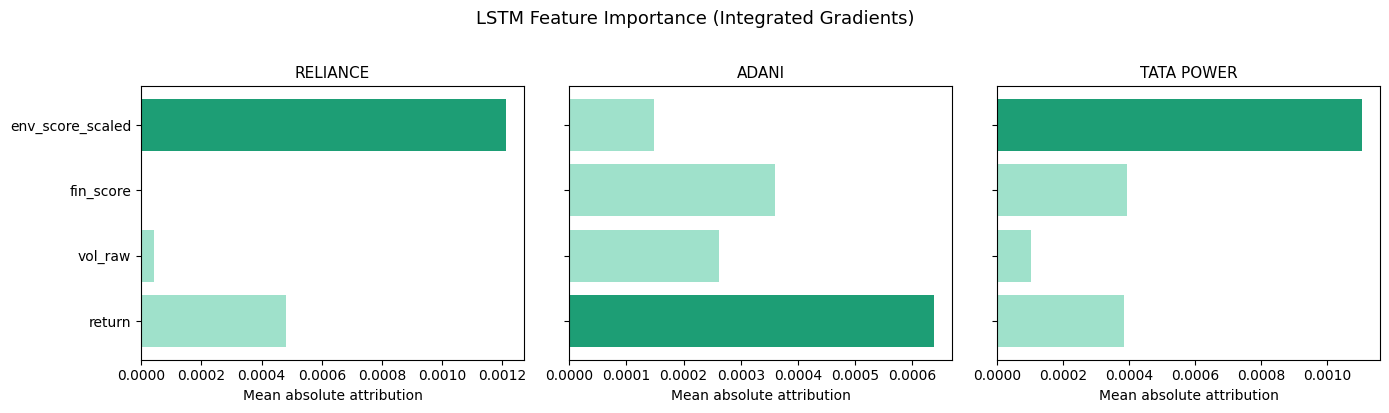

In [ ]:

# -- Plot LSTM Integrated Gradients: mean absolute importance per feature -------
if not lstm_explanations:
    print("No LSTM attributions available. Run the attribution cell first.")
else:
    fig, axes = plt.subplots(nrows=1, ncols=min(3, len(lstm_explanations)), figsize=(14, 4), sharey=True)
    if len(lstm_explanations) == 1:
        axes = [axes]

    for ax, (company, sv) in zip(axes, list(lstm_explanations.items())[:3]):
        mean_abs = np.abs(sv).mean(axis=(0, 1))
        ax.barh(FEATURE_NAMES, mean_abs,
                color=['#1D9E75' if v == mean_abs.max() else '#9FE1CB' for v in mean_abs])
        ax.set_title(company, fontsize=11)
        ax.set_xlabel('Mean absolute attribution')
        ax.axvline(0, color='black', lw=0.5)

    plt.suptitle('LSTM Feature Importance (Integrated Gradients)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{SHAP_OUT_DIR}LSTM_feature_importance_IG.png', dpi=150, bbox_inches='tight')
    plt.show()


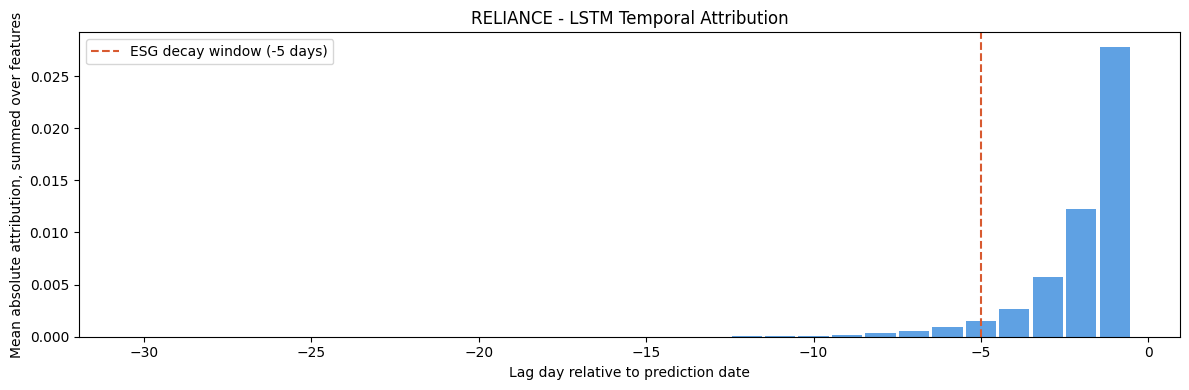

In [ ]:

# -- Plot LSTM temporal attribution by lag day ----------------------------------
if not lstm_explanations:
    print("No LSTM attributions available. Run the attribution cell first.")
else:
    company = list(lstm_explanations.keys())[0]
    sv = lstm_explanations[company]

    temporal_importance = np.abs(sv).sum(axis=2)
    mean_temporal = temporal_importance.mean(axis=0)
    lags = list(range(-sv.shape[1], 0))

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(lags, mean_temporal, color='#378ADD', alpha=0.8, width=0.9)
    ax.axvline(-ESG_DECAY_DAYS, color='#D85A30', linestyle='--', lw=1.5,
               label=f'ESG decay window (-{ESG_DECAY_DAYS} days)')
    ax.set_xlabel('Lag day relative to prediction date')
    ax.set_ylabel('Mean absolute attribution, summed over features')
    ax.set_title(f'{company} - LSTM Temporal Attribution')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{SHAP_OUT_DIR}LSTM_temporal_attribution_IG_{company}.png', dpi=150, bbox_inches='tight')
    plt.show()


## Section 6 — Research Outputs & Visualisations
Answers all three RQs with publication-ready figures.


In [ ]:
# ============================================================
# Section 6 — Final Research Insights
# Uses only defensible outputs from Sections 3, 4, 5
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULT_OUT_DIR = SHAP_OUT_DIR if 'SHAP_OUT_DIR' in globals() else '/content/drive/MyDrive/SHAP_outputs/'
os.makedirs(RESULT_OUT_DIR, exist_ok=True)

print("Section 6 output directory:", RESULT_OUT_DIR)

Section 6 output directory: /content/drive/MyDrive/SHAP_outputs/


In [ ]:
# ============================================================
# Helper: detect event-window AR columns
# ============================================================

def get_ar_columns(df):
    ar_cols = []

    for c in df.columns:
        m = re.match(r'^AR_([+-]?\d+)$', str(c))
        if m:
            ar_cols.append((int(m.group(1)), c))

    ar_cols = sorted(ar_cols, key=lambda x: x[0])
    return ar_cols


if 'event_path_df' not in globals():
    raise RuntimeError("event_path_df not found. Run the event-study section first.")

event_plot_df = event_path_df.copy()

if 'event_date' in event_plot_df.columns:
    event_plot_df['event_date'] = pd.to_datetime(event_plot_df['event_date'])

if 'Headline' not in event_plot_df.columns and 'Headlines' in event_plot_df.columns:
    event_plot_df['Headline'] = event_plot_df['Headlines']

ar_cols = get_ar_columns(event_plot_df)

print("Event-path rows:", len(event_plot_df))
print("Detected AR columns:", ar_cols[:5], "...", ar_cols[-5:])

Event-path rows: 218
Detected AR columns: [(-5, 'AR_-5'), (-4, 'AR_-4'), (-3, 'AR_-3'), (-2, 'AR_-2'), (-1, 'AR_-1')] ... [(6, 'AR_+6'), (7, 'AR_+7'), (8, 'AR_+8'), (9, 'AR_+9'), (10, 'AR_+10')]


Skipping Negative: only N=3 events


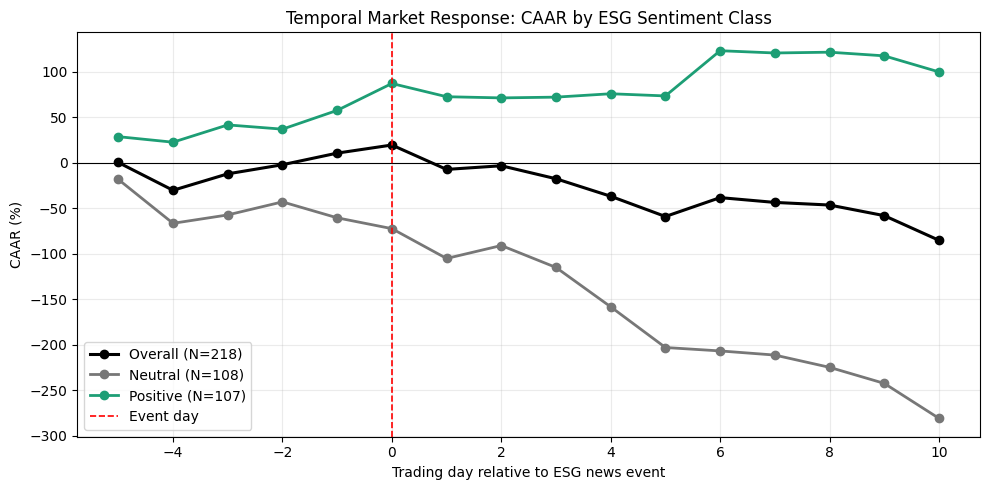

In [ ]:
# ============================================================
# Figure 6.1 — CAAR by sentiment class with sample counts
# ============================================================

if not ar_cols:
    print("No AR path columns found. Skipping CAAR plot.")
else:
    days = [x[0] for x in ar_cols]
    cols = [x[1] for x in ar_cols]

    fig, ax = plt.subplots(figsize=(10, 5))

    # Overall CAAR
    ar_matrix = event_plot_df[cols].replace([np.inf, -np.inf], np.nan).dropna().values
    if len(ar_matrix) > 0:
        overall_caar = np.nanmean(ar_matrix, axis=0).cumsum() * 100
        ax.plot(days, overall_caar, color='black', lw=2.2, marker='o',
                label=f'Overall (N={len(ar_matrix)})')

    colors = {
        'Positive': '#1D9E75',
        'Neutral': '#777777',
        'Negative': '#E24B4A'
    }

    for sentiment, grp in event_plot_df.groupby('sentiment'):
        ar_matrix = grp[cols].replace([np.inf, -np.inf], np.nan).dropna().values

        # Avoid misleading tiny classes
        if len(ar_matrix) < 10:
            print(f"Skipping {sentiment}: only N={len(ar_matrix)} events")
            continue

        caar = np.nanmean(ar_matrix, axis=0).cumsum() * 100

        ax.plot(
            days,
            caar,
            marker='o',
            lw=2,
            color=colors.get(sentiment, None),
            label=f'{sentiment} (N={len(ar_matrix)})'
        )

    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(0, color='red', linestyle='--', lw=1.2, label='Event day')
    ax.set_title('Temporal Market Response: CAAR by ESG Sentiment Class')
    ax.set_xlabel('Trading day relative to ESG news event')
    ax.set_ylabel('CAAR (%)')
    ax.legend()
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(f'{RESULT_OUT_DIR}Fig6_1_CAAR_by_sentiment_final.png',
                dpi=220, bbox_inches='tight')
    plt.show()

In [ ]:
# ============================================================
# Figure 6.2 — Volatility / attention response after ESG news
# ============================================================

if 'vol_path_df' in globals():
    vol_plot_df = vol_path_df.copy()

    abs_cols = []
    for c in vol_plot_df.columns:
        m = re.match(r'^ABSRET_([+-]?\d+)$', str(c))
        if m:
            abs_cols.append((int(m.group(1)), c))

    abs_cols = sorted(abs_cols, key=lambda x: x[0])

    if abs_cols:
        days_abs = [x[0] for x in abs_cols]
        cols_abs = [x[1] for x in abs_cols]

        mean_abs = vol_plot_df[cols_abs].mean(axis=0).values * 100

        fig, ax = plt.subplots(figsize=(10, 4.5))
        ax.plot(days_abs, mean_abs, marker='o', lw=2.2, color='#D85A30')
        ax.axvline(0, color='red', linestyle='--', lw=1.2)
        ax.set_title('Volatility Proxy: Average Absolute Return Around ESG News')
        ax.set_xlabel('Trading day relative to ESG news event')
        ax.set_ylabel('Mean absolute return (%)')
        ax.grid(alpha=0.25)

        plt.tight_layout()
        plt.savefig(f'{RESULT_OUT_DIR}Fig6_2_abs_return_response_final.png',
                    dpi=220, bbox_inches='tight')
        plt.show()

    else:
        print("vol_path_df found, but no ABSRET path columns found.")
else:
    print("vol_path_df not found. Skipping volatility-response figure.")

vol_path_df not found. Skipping volatility-response figure.


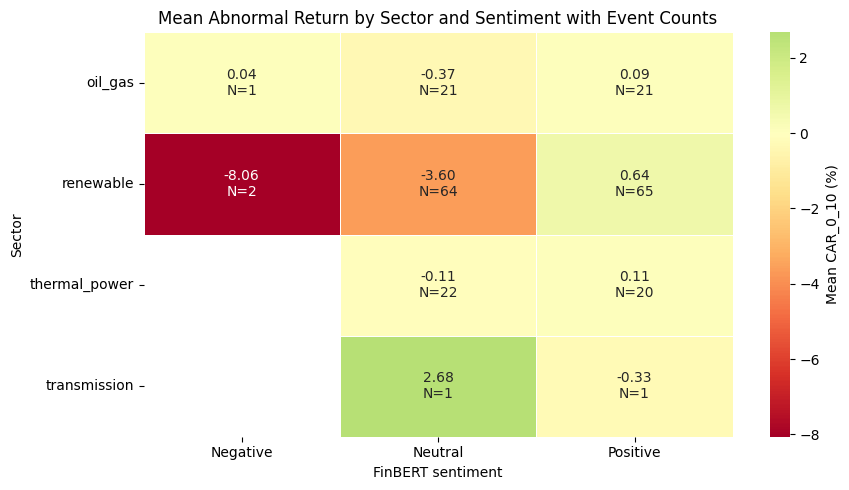

In [ ]:
# ============================================================
# Figure 6.3 — Sector × sentiment CAR heatmap WITH counts
# ============================================================

heat_df = event_plot_df.copy()

car_col = None
for candidate in ['CAR_0_10', 'CAR', 'CAR_-1_5']:
    if candidate in heat_df.columns:
        car_col = candidate
        break

if car_col is None:
    print("No CAR column found. Skipping sector heatmap.")
elif 'sector' not in heat_df.columns:
    print("No sector column found. Skipping sector heatmap.")
else:
    heat_df = heat_df.dropna(subset=[car_col, 'sector', 'sentiment']).copy()

    mean_pivot = heat_df.pivot_table(
        index='sector',
        columns='sentiment',
        values=car_col,
        aggfunc='mean'
    )

    count_pivot = heat_df.pivot_table(
        index='sector',
        columns='sentiment',
        values=car_col,
        aggfunc='count'
    )

    # Convert CAR to percent only if values look like decimal returns
    if mean_pivot.abs().max().max() < 1:
        mean_pivot_plot = mean_pivot * 100
    else:
        mean_pivot_plot = mean_pivot.copy()

    annot = mean_pivot_plot.copy().astype(object)

    for r in annot.index:
        for c in annot.columns:
            val = mean_pivot_plot.loc[r, c]
            n = count_pivot.loc[r, c] if c in count_pivot.columns else np.nan

            if pd.isna(val):
                annot.loc[r, c] = ''
            else:
                annot.loc[r, c] = f'{val:.2f}\nN={int(n)}'

    fig, ax = plt.subplots(figsize=(9, 5))

    sns.heatmap(
        mean_pivot_plot,
        annot=annot,
        fmt='',
        cmap='RdYlGn',
        center=0,
        linewidths=0.5,
        cbar_kws={'label': f'Mean {car_col} (%)'},
        ax=ax
    )

    ax.set_title('Mean Abnormal Return by Sector and Sentiment with Event Counts')
    ax.set_xlabel('FinBERT sentiment')
    ax.set_ylabel('Sector')

    plt.tight_layout()
    plt.savefig(f'{RESULT_OUT_DIR}Fig6_3_sector_sentiment_heatmap_counts.png',
                dpi=220, bbox_inches='tight')
    plt.show()

In [ ]:
# ============================================================
# Figure 6.4 — LSTM ablation summary, not overclaimed
# ============================================================

ablation_obj = None

for name in ['ablation_df', 'lstm_ablation_df', 'ablation_results_df', 'abl']:
    if name in globals():
        ablation_obj = globals()[name]
        print(f"Using {name}")
        break

if ablation_obj is None:
    print("No LSTM ablation dataframe found. Skipping LSTM summary.")
else:
    ab = ablation_obj.copy()

    if 'Improvement' in ab.columns:
        improved = ab['Improvement'].astype(str).str.upper().eq('YES').sum()
        total = len(ab)
    elif 'Delta_RMSE' in ab.columns:
        improved = (ab['Delta_RMSE'] > 0).sum()
        total = len(ab)
    else:
        improved, total = np.nan, len(ab)

    mean_delta_rmse = ab['Delta_RMSE'].mean() if 'Delta_RMSE' in ab.columns else np.nan
    mean_delta_mae = ab['Delta_MAE'].mean() if 'Delta_MAE' in ab.columns else np.nan

    print("=" * 70)
    print("LSTM ESG FEATURE ABLATION SUMMARY")
    print("=" * 70)
    print(f"Companies improved with ESG features: {improved} / {total}")
    print(f"Mean Delta_RMSE: {mean_delta_rmse:.6f}" if pd.notna(mean_delta_rmse) else "Mean Delta_RMSE: NA")
    print(f"Mean Delta_MAE : {mean_delta_mae:.6f}" if pd.notna(mean_delta_mae) else "Mean Delta_MAE: NA")
    print("\nInterpretation:")
    print("ESG features do not consistently improve LSTM volatility prediction.")
    print("The LSTM is retained as an exploratory benchmark, not as the main evidence.")
    print("=" * 70)

    display(ab)

Using abl
LSTM ESG FEATURE ABLATION SUMMARY
Companies improved with ESG features: 6 / 11
Mean Delta_RMSE: 0.000045
Mean Delta_MAE : 0.000132

Interpretation:
ESG features do not consistently improve LSTM volatility prediction.
The LSTM is retained as an exploratory benchmark, not as the main evidence.


,Company,MAE_ESG,MAE_Baseline,Delta_MAE,RMSE_ESG,RMSE_Baseline,Delta_RMSE,Improvement
0,RELIANCE,0.005758,0.004866,-0.000892,0.006852,0.006120,-0.000731,NO
1,ADANI,0.014597,0.014413,-0.000184,0.023371,0.022459,-0.000912,NO
2,TATA POWER,0.005549,0.006056,0.000507,0.007240,0.007789,0.000548,YES
3,NTPC,0.005239,0.006615,0.001376,0.006793,0.008202,0.001409,YES
4,ONGC,0.006963,0.007443,0.000480,0.009122,0.009297,0.000175,YES
5,JSW,0.010234,0.008857,-0.001376,0.012295,0.011269,-0.001026,NO
6,NHPC,0.006977,0.006054,-0.000922,0.009455,0.008028,-0.001427,NO
7,POWER GRID,0.004432,0.004301,-0.000131,0.005672,0.005569,-0.000103,NO
8,BPCL,0.005677,0.006117,0.000440,0.007246,0.007353,0.000108,YES
9,GAIL,0.006585,0.008213,0.001628,0.007932,0.010043,0.002111,YES


In [ ]:
# ============================================================
# Figure 6.5 — SHAP headline explanation summary
# ============================================================

if 'shap_summary_df' not in globals():
    possible_path = f'{RESULT_OUT_DIR}shap_saved_summary_entity_phrase.csv'

    if os.path.exists(possible_path):
        shap_summary_df = pd.read_csv(possible_path)
        print("Loaded SHAP summary:", possible_path)
    else:
        shap_summary_df = None

if shap_summary_df is None:
    print("No SHAP summary found. Run SHAP section first.")
else:
    cols_to_show = [
        c for c in [
            'shap_group',
            'company',
            'sentiment',
            'CAR_0_10',
            'fin_top_units',
            'env_top_units',
            'headline'
        ]
        if c in shap_summary_df.columns
    ]

    print("=" * 70)
    print("SHAP EXPLANATION SUMMARY")
    print("=" * 70)
    print("These are impact-selected headlines, not random samples.")
    print("FinBERT SHAP explains financial sentiment terms.")
    print("Environmental SHAP explains ESG-materiality terms.")
    print("=" * 70)

    display(shap_summary_df[cols_to_show].head(12))

Loaded SHAP summary: /content/drive/MyDrive/SHAP_outputs/shap_saved_summary_entity_phrase.csv
SHAP EXPLANATION SUMMARY
These are impact-selected headlines, not random samples.
FinBERT SHAP explains financial sentiment terms.
Environmental SHAP explains ESG-materiality terms.


,shap_group,company,sentiment,CAR_0_10,fin_top_units,env_top_units,headline
0,positive_high_CAR,ADANI,Positive,49.163348,"by, renewable, approved, group, energy","projects, energy, approved, Sri Lanka, Adani",Adani group's renewable energy projects approved by Sri Lanka
1,positive_high_CAR,ADANI,Positive,43.285570,"Adani Total Gas, green, pilot, hydrogen, project","hydrogen, blending, green, launches, pilot",Adani Total Gas launches green hydrogen blending pilot project
2,positive_high_CAR,ADANI,Positive,30.916398,"$1.36 billion, renewable energy park, for, more, Gujarat","renewable energy park, raises, more, in, $1.36 billion",Adani Green raises $1.36 billion more for renewable energy park in Gujarat
3,positive_high_CAR,JSW,Positive,11.295307,"use, Rs 10K cr, JSW Steel, Sajjan Jindal, emissions","Energy, Sajjan Jindal, Renewable, Rs 10K cr, renewable energy","JSW Steel | Renewable Energy: JSW Steel to invest Rs 10K cr to increase use of renewable energy, reduce emissions: S..."
4,positive_high_CAR,ADANI,Positive,10.881496,"Druk Green Power, MoU, 5, develop, with","hydropower projects, in, Druk Green Power, to, 5","Adani Group signs MoU with Druk Green Power to develop 5,000 MW of hydropower projects in Bhutan"
5,positive_high_CAR,ADANI,Positive,10.849598,"as, Adani Green Energy, for, How, &","emerged, Adani Green Energy, &, of, new grid",ET Awards for Corporate Excellence: How Adani Green Energy emerged as renewable & clean's new grid of life
6,positive_high_CAR,NTPC,Positive,10.784384,"at, additional 42.5MW capacity, commissions, Ramagundam, floating solar project","floating solar project, additional 42.5MW capacity, Ramagundam, NTPC, commissions",NTPC commissions additional 42.5MW capacity at Ramagundam floating solar project
7,positive_high_CAR,ONGC,Positive,10.313896,"partners, gas flaring, to, cut, 2030","zero methane emission, by, 2030, ONGC, to","ONGC seeks partners to cut gas flaring, zero methane emission by 2030"
8,positive_high_CAR,TATA POWER,Positive,8.078675,"onsite solar project, develop, PPA, Tata Power, with","onsite solar project, to, signs, PPA, with",Tata Motors signs PPA with Tata Power to develop onsite solar project
9,positive_high_CAR,TATA POWER,Positive,7.955961,"20GW solar capacity, achieve, by, Rs, 75,000 cr","20GW solar capacity, 2030, arm, by, pledges","Tata Power arm pledges Rs 75,000 cr to achieve 20GW solar capacity by 2030"


In [ ]:
# ============================================================
# Final written research summary
# ============================================================

summary_lines = []

summary_lines.append("FINAL RESEARCH SUMMARY")
summary_lines.append("=" * 70)

summary_lines.append("\n1. Temporal market impact")
summary_lines.append(
    "Event-study results show heterogeneous market reaction to ESG news. "
    "Aggregate CAR effects are weak, so the project does not claim strong universal return predictability."
)

summary_lines.append("\n2. Sentiment and sector differences")
summary_lines.append(
    "Positive ESG-energy headlines show more favorable CAAR patterns than neutral headlines, "
    "but small sentiment-sector cells must be interpreted cautiously."
)

summary_lines.append("\n3. Volatility response")
summary_lines.append(
    "Absolute-return patterns suggest ESG news may be more visible as a volatility or attention signal "
    "than as a clean directional return predictor."
)

summary_lines.append("\n4. LSTM benchmark")
summary_lines.append(
    "The LSTM provides an exploratory temporal benchmark. ESG features do not consistently improve "
    "prediction across all companies, so deep learning is not treated as the main evidence."
)

summary_lines.append("\n5. SHAP explainability")
summary_lines.append(
    "SHAP explains why FinBERT and the environmental materiality model scored selected market-impactful "
    "headlines the way they did. Final SHAP plots are aggregated to named entities, noun phrases, "
    "and meaningful words for interpretability."
)

summary_lines.append("\nOverall conclusion")
summary_lines.append(
    "The strongest contribution is an interpretable ESG-news-to-market-impact analysis pipeline, "
    "not a high-accuracy stock prediction model."
)

final_summary = "\n".join(summary_lines)

print(final_summary)

with open(f'{RESULT_OUT_DIR}final_research_summary.txt', 'w', encoding='utf-8') as f:
    f.write(final_summary)

print("\nSaved final summary to:", f'{RESULT_OUT_DIR}final_research_summary.txt')

FINAL RESEARCH SUMMARY

1. Temporal market impact
Event-study results show heterogeneous market reaction to ESG news. Aggregate CAR effects are weak, so the project does not claim strong universal return predictability.

2. Sentiment and sector differences
Positive ESG-energy headlines show more favorable CAAR patterns than neutral headlines, but small sentiment-sector cells must be interpreted cautiously.

3. Volatility response
Absolute-return patterns suggest ESG news may be more visible as a volatility or attention signal than as a clean directional return predictor.

4. LSTM benchmark
The LSTM provides an exploratory temporal benchmark. ESG features do not consistently improve prediction across all companies, so deep learning is not treated as the main evidence.

5. SHAP explainability
SHAP explains why FinBERT and the environmental materiality model scored selected market-impactful headlines the way they did. Final SHAP plots are aggregated to named entities, noun phrases, and me